# Checkpoint History Error Analysis: v7, v8, v9 vs v5 Benchmark

This notebook compares all autoencoder checkpoint histories in `v7`, `v8`, and `v9` against the benchmark checkpoint in `v5`.

Scope:

- Training/validation history from `Code/results/autoencoder/solubility/{v5,v7,v8,v9}`.
- Test teacher-forced and autoregressive metrics from history JSON files when available, with `Code/results/tables/autoencoder_results.csv` used as the common test-metric source and to fill v5.
- Error analysis is metric-level: loss, accuracy, generalization gap, validation drift, and systematic differences by length split, latent dimension, and teacher-forcing dropout. It does not inspect per-sequence reconstruction errors because those artifacts are not present for these checkpoints.


In [97]:
from pathlib import Path
import json
import math
import re

import matplotlib.pyplot as plt
import pandas as pd

if "__file__" in globals():
    NOTEBOOK_DIR = Path(__file__).resolve().parent
else:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR
for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (candidate / "Code" / "results" / "tables" / "autoencoder_results.csv").exists():
        PROJECT_ROOT = candidate
        break

RESULTS_ROOT = PROJECT_ROOT / "Code" / "results" / "autoencoder" / "solubility"
RESULTS_TABLE = PROJECT_ROOT / "Code" / "results" / "tables" / "autoencoder_results.csv"
CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints" / "autoencoder" / "solubility"
VERSIONS = ["v5", "v7", "v8", "v9"]
BENCHMARK_VERSION = "v5"

plt.style.use("default")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

print(f"Project root: {PROJECT_ROOT}")
print(f"History root: {RESULTS_ROOT}")
print(f"Results table: {RESULTS_TABLE}")




Project root: /Users/josh/GWU/protein-sequence-augmentation
History root: /Users/josh/GWU/protein-sequence-augmentation/Code/results/autoencoder/solubility
Results table: /Users/josh/GWU/protein-sequence-augmentation/Code/results/tables/autoencoder_results.csv


## Load Histories and Test Metrics

The loader keeps the v5 benchmark and every v7-v9 history. It parses length split, latent dimension, and teacher-forcing dropout from checkpoint names when present, then merges final test metrics from the shared results CSV.


In [98]:
def parse_run_metadata(version, history_path, history):
    stem = history_path.name.removesuffix("_history.json")
    model_name = stem
    if model_name.startswith(f"{version}_"):
        model_name = model_name[len(version) + 1:]

    hp = history.get("hyperparameters", {})
    length_match = re.search(r"length_(\d+)_of_(\d+)", model_name)
    latent_match = re.search(r"latent(\d+)", model_name)
    tfd_match = re.search(r"tfd(\d+)p(\d+)", model_name)

    if tfd_match:
        tfd = float(f"{tfd_match.group(1)}.{tfd_match.group(2)}")
    else:
        tfd = hp.get("teacher_forcing_dropout_rate")

    if length_match:
        length_numerator = int(length_match.group(1))
        length_denominator = int(length_match.group(2))
        length_group = f"{length_numerator}/{length_denominator}"
        length_fraction = length_numerator / length_denominator
    else:
        length_numerator = math.nan
        length_denominator = math.nan
        length_group = "benchmark/full"
        length_fraction = math.nan

    if version == "v5" and model_name == "solubility_ae":
        checkpoint_name = "model_ae_solubility"
    else:
        checkpoint_name = model_name.replace("_history", "")
    checkpoint_path = CHECKPOINT_ROOT / version / f"{checkpoint_name}.pt"

    return {
        "version": version,
        "history_path": str(history_path.relative_to(PROJECT_ROOT)),
        "run_id": f"{version}:{model_name}",
        "model_name": model_name,
        "checkpoint": str(checkpoint_path.relative_to(PROJECT_ROOT)),
        "length_group": length_group,
        "length_numerator": length_numerator,
        "length_denominator": length_denominator,
        "length_fraction": length_fraction,
        "latent_dim": int(latent_match.group(1)) if latent_match else hp.get("latent_dim"),
        "teacher_forcing_dropout": tfd,
        "curriculum_type": history.get("curriculum", {}).get("type"),
        "curriculum_epochs": history.get("curriculum", {}).get("epochs"),
        "num_epochs_requested": hp.get("num_epochs"),
    }


def load_histories(versions):
    runs = []
    for version in versions:
        version_dir = RESULTS_ROOT / version
        for history_path in sorted(version_dir.glob("*history.json")):
            with history_path.open() as f:
                history = json.load(f)
            metadata = parse_run_metadata(version, history_path, history)
            metadata["history"] = history
            runs.append(metadata)
    return runs


runs = load_histories(VERSIONS)
print(f"Loaded {len(runs)} histories")
pd.Series([run["version"] for run in runs]).value_counts().sort_index().rename("history_count")



Loaded 49 histories


v5     1
v7    18
v8    12
v9    18
Name: history_count, dtype: int64

In [99]:
def history_metric(history, split, metric):
    values = history.get(f"{split}_scores", {}).get(metric)
    return values if isinstance(values, list) else []


def flatten_epochs(runs):
    rows = []
    for run in runs:
        history = run["history"]
        epochs = history.get("epochs", [])
        for idx, epoch_record in enumerate(epochs):
            row = {k: v for k, v in run.items() if k != "history"}
            row.update(
                {
                    "epoch": epoch_record.get("epoch", idx + 1),
                    "train_loss": epoch_record.get("train_loss"),
                    "val_loss": epoch_record.get("val_loss"),
                    "train_accuracy": epoch_record.get("train_accuracy"),
                    "val_accuracy": epoch_record.get("val_accuracy"),
                    "train_f1": epoch_record.get("train_f1"),
                    "curriculum_fraction": epoch_record.get("curriculum_fraction"),
                    "curriculum_examples": epoch_record.get("curriculum_examples"),
                }
            )
            rows.append(row)
    return pd.DataFrame(rows)


def summarize_run(run):
    history = run["history"]
    epochs = pd.DataFrame(history.get("epochs", []))
    row = {k: v for k, v in run.items() if k != "history"}
    row["epochs_completed"] = len(epochs)

    if epochs.empty:
        return row

    best_loss_idx = epochs["val_loss"].idxmin()
    best_acc_idx = epochs["val_accuracy"].idxmax()
    final = epochs.iloc[-1]
    best_loss = epochs.loc[best_loss_idx]
    best_acc = epochs.loc[best_acc_idx]

    row.update(
        {
            "final_train_loss": final.get("train_loss"),
            "final_val_loss": final.get("val_loss"),
            "final_train_accuracy": final.get("train_accuracy"),
            "final_val_accuracy": final.get("val_accuracy"),
            "best_val_loss": best_loss.get("val_loss"),
            "best_val_loss_epoch": int(best_loss.get("epoch")),
            "best_val_loss_accuracy": best_loss.get("val_accuracy"),
            "best_val_accuracy": best_acc.get("val_accuracy"),
            "best_val_accuracy_epoch": int(best_acc.get("epoch")),
            "best_val_accuracy_loss": best_acc.get("val_loss"),
            "loss_generalization_gap_final": final.get("val_loss") - final.get("train_loss"),
            "accuracy_generalization_gap_final": final.get("train_accuracy") - final.get("val_accuracy"),
            "val_loss_drift_after_best": final.get("val_loss") - best_loss.get("val_loss"),
            "val_accuracy_drift_after_best": best_acc.get("val_accuracy") - final.get("val_accuracy"),
            "tail_val_loss_std": epochs["val_loss"].tail(min(10, len(epochs))).std(),
            "tail_val_accuracy_std": epochs["val_accuracy"].tail(min(10, len(epochs))).std(),
        }
    )

    test = history.get("test", {})
    row["history_test_tf_loss"] = test.get("teacher_forced", {}).get("loss")
    row["history_test_tf_accuracy"] = test.get("teacher_forced", {}).get("accuracy")
    row["history_test_ar_loss"] = test.get("autoregressive", {}).get("loss", history.get("test_loss"))
    row["history_test_ar_accuracy"] = test.get("autoregressive", {}).get("accuracy", history.get("test_accuracy"))
    return row


epoch_df = flatten_epochs(runs)
summary_df = pd.DataFrame([summarize_run(run) for run in runs])

results_df = pd.read_csv(RESULTS_TABLE)
results_df = results_df.rename(
    columns={
        "file name": "checkpoint",
        "test teacher force loss": "csv_test_tf_loss",
        "test autoregressive loss": "csv_test_ar_loss",
        "test teacher forced accuracy": "csv_test_tf_accuracy",
        "test autoregressive accuracy": "csv_test_ar_accuracy",
    }
)
metric_cols = [c for c in results_df.columns if c.startswith("csv_test")]
results_df[metric_cols] = results_df[metric_cols].apply(pd.to_numeric, errors="coerce")

summary_df = summary_df.merge(results_df[["checkpoint", *metric_cols]], on="checkpoint", how="left")
for target, history_col, csv_col in [
    ("test_tf_loss", "history_test_tf_loss", "csv_test_tf_loss"),
    ("test_tf_accuracy", "history_test_tf_accuracy", "csv_test_tf_accuracy"),
    ("test_ar_loss", "history_test_ar_loss", "csv_test_ar_loss"),
    ("test_ar_accuracy", "history_test_ar_accuracy", "csv_test_ar_accuracy"),
]:
    summary_df[target] = summary_df[history_col].combine_first(summary_df[csv_col])

benchmark = summary_df.loc[summary_df["version"].eq(BENCHMARK_VERSION)].iloc[0]
for col in ["test_tf_loss", "test_ar_loss", "test_tf_accuracy", "test_ar_accuracy", "best_val_loss", "best_val_accuracy"]:
    summary_df[f"delta_vs_v5_{col}"] = summary_df[col] - benchmark[col]

summary_df["beats_v5_tf_loss"] = summary_df["test_tf_loss"] < benchmark["test_tf_loss"]
summary_df["beats_v5_tf_accuracy"] = summary_df["test_tf_accuracy"] > benchmark["test_tf_accuracy"]
summary_df["beats_v5_ar_loss"] = summary_df["test_ar_loss"] < benchmark["test_ar_loss"]
summary_df["beats_v5_ar_accuracy"] = summary_df["test_ar_accuracy"] > benchmark["test_ar_accuracy"]

print(f"Epoch rows: {len(epoch_df):,}")
print(f"Summary rows: {len(summary_df):,}")
summary_df.head()



Epoch rows: 4,156
Summary rows: 49


,version,history_path,run_id,model_name,checkpoint,length_group,length_numerator,length_denominator,length_fraction,latent_dim,teacher_forcing_dropout,curriculum_type,curriculum_epochs,num_epochs_requested,epochs_completed,final_train_loss,final_val_loss,final_train_accuracy,final_val_accuracy,best_val_loss,best_val_loss_epoch,best_val_loss_accuracy,best_val_accuracy,best_val_accuracy_epoch,best_val_accuracy_loss,loss_generalization_gap_final,accuracy_generalization_gap_final,val_loss_drift_after_best,val_accuracy_drift_after_best,tail_val_loss_std,tail_val_accuracy_std,history_test_tf_loss,history_test_tf_accuracy,history_test_ar_loss,history_test_ar_accuracy,csv_test_tf_loss,csv_test_ar_loss,csv_test_tf_accuracy,csv_test_ar_accuracy,test_tf_loss,test_tf_accuracy,test_ar_loss,test_ar_accuracy,delta_vs_v5_test_tf_loss,delta_vs_v5_test_ar_loss,delta_vs_v5_test_tf_accuracy,delta_vs_v5_test_ar_accuracy,delta_vs_v5_best_val_loss,delta_vs_v5_best_val_accuracy,beats_v5_tf_loss,beats_v5_tf_accuracy,beats_v5_ar_loss,beats_v5_ar_accuracy
0,v5,Code/results/autoencoder/solubility/v5/solubil...,v5:solubility_ae,solubility_ae,checkpoints/autoencoder/solubility/v5/model_ae...,benchmark/full,NaN,NaN,NaN,512,0.30,length,5,100,100,1.034647,1.050459,0.596518,0.596226,1.050459,100,0.596226,0.596226,100,1.050459,0.015812,0.000292,0.000000,0.000000,0.007382,0.003088,NaN,NaN,NaN,NaN,1.131063,3.344341,0.581860,0.253772,1.131063,0.581860,3.344341,0.253772,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False,False
1,v7,Code/results/autoencoder/solubility/v7/v7_mode...,v7:model_ae_length_1_of_3_solubility_latent128...,model_ae_length_1_of_3_solubility_latent128_tf...,checkpoints/autoencoder/solubility/v7/model_ae...,1/3,1.0,3.0,0.333333,128,0.30,none,0,100,61,1.354944,1.722791,0.494016,0.401372,1.720914,51,0.396907,0.401433,59,1.721490,0.367847,0.092645,0.001876,0.000062,0.005321,0.002038,1.715858,0.407279,3.048065,0.185505,1.715873,3.050803,0.407279,0.185523,1.715858,0.407279,3.048065,0.185505,0.584795,-0.296276,-0.174581,-0.068267,0.670455,-0.194793,False,False,True,False
2,v7,Code/results/autoencoder/solubility/v7/v7_mode...,v7:model_ae_length_1_of_3_solubility_latent128...,model_ae_length_1_of_3_solubility_latent128_tf...,checkpoints/autoencoder/solubility/v7/model_ae...,1/3,1.0,3.0,0.333333,128,0.45,none,0,100,85,1.208313,1.575491,0.538900,0.442884,1.574288,75,0.442430,0.442884,85,1.575491,0.367177,0.096016,0.001203,0.000000,0.000388,0.000344,1.569996,0.453481,3.123034,0.212208,1.570005,3.122920,0.453517,0.212182,1.569996,0.453481,3.123034,0.212208,0.438933,-0.221307,-0.128379,-0.041564,0.523828,-0.153342,False,False,True,False
3,v7,Code/results/autoencoder/solubility/v7/v7_mode...,v7:model_ae_length_1_of_3_solubility_latent256...,model_ae_length_1_of_3_solubility_latent256_tf...,checkpoints/autoencoder/solubility/v7/model_ae...,1/3,1.0,3.0,0.333333,256,0.30,none,0,100,74,1.166707,1.527663,0.550553,0.454265,1.525767,64,0.453792,0.454265,74,1.527663,0.360955,0.096288,0.001896,0.000000,0.000771,0.000180,1.510360,0.468241,3.072792,0.227952,1.510381,3.070550,0.468133,0.227782,1.510360,0.468241,3.072792,0.227952,0.379297,-0.271549,-0.113619,-0.025820,0.475307,-0.141961,False,False,True,False
4,v7,Code/results/autoencoder/solubility/v7/v7_mode...,v7:model_ae_length_1_of_3_solubility_latent256...,model_ae_length_1_of_3_solubility_latent256_tf...,checkpoints/autoencoder/solubility/v7/model_ae...,1/3,1.0,3.0,0.333333,256,0.45,none,0,100,68,1.236231,1.534286,0.527266,0.447968,1.532652,58,0.447486,0.448035,65,1.534247,0.298055,0.079298,0.001633,0.000067,0.000536,0.000345,1.517767,0.461786,2.998510,0.221622,1.517796,2.997490,0.461715,0.221926,1.517767,0.461786,2.998510,0.221622,0.386704,-0.345831,-0.120074,-0.032150,0.482193,-0.148191,False,False,True,False


## Benchmark Reference

These are the v5 values used for every delta. Negative loss deltas are better; positive accuracy deltas are better.


In [100]:
benchmark_cols = [
    "run_id",
    "checkpoint",
    "epochs_completed",
    "best_val_loss",
    "best_val_accuracy",
    "test_tf_loss",
    "test_tf_accuracy",
    "test_ar_loss",
    "test_ar_accuracy",
]
summary_df.loc[summary_df["version"].eq(BENCHMARK_VERSION), benchmark_cols]



,run_id,checkpoint,epochs_completed,best_val_loss,best_val_accuracy,test_tf_loss,test_tf_accuracy,test_ar_loss,test_ar_accuracy
0,v5:solubility_ae,checkpoints/autoencoder/solubility/v5/model_ae...,100,1.050459,0.596226,1.131063,0.58186,3.344341,0.253772


## Overall Test Error Comparison

The table ranks v7-v9 by teacher-forced test loss, because that is closest to the training objective. Autoregressive metrics are kept beside it because they better reflect free-running reconstruction quality.


In [101]:
comparison_cols = [
    "version",
    "model_name",
    "length_group",
    "latent_dim",
    "teacher_forcing_dropout",
    "epochs_completed",
    "test_tf_loss",
    "delta_vs_v5_test_tf_loss",
    "test_tf_accuracy",
    "delta_vs_v5_test_tf_accuracy",
    "test_ar_loss",
    "delta_vs_v5_test_ar_loss",
    "test_ar_accuracy",
    "delta_vs_v5_test_ar_accuracy",
    "best_val_loss",
    "best_val_accuracy",
    "loss_generalization_gap_final",
]

ranked = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"]), comparison_cols]
    .sort_values(["test_tf_loss", "test_ar_accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)
ranked.head(20)



,version,model_name,length_group,latent_dim,teacher_forcing_dropout,epochs_completed,test_tf_loss,delta_vs_v5_test_tf_loss,test_tf_accuracy,delta_vs_v5_test_tf_accuracy,test_ar_loss,delta_vs_v5_test_ar_loss,test_ar_accuracy,delta_vs_v5_test_ar_accuracy,best_val_loss,best_val_accuracy,loss_generalization_gap_final
0,v9,model_ae_length_2_of_3_solubility_latent512_tf...,2/3,512,0.30,100,0.735418,-0.395645,0.709003,0.127143,3.215062,-0.129279,0.364371,0.110599,0.753443,0.694954,0.039192
1,v9,model_ae_length_2_of_3_solubility_latent512_tf...,2/3,512,0.45,100,0.736249,-0.394814,0.710039,0.128179,3.184764,-0.159577,0.369638,0.115866,0.753699,0.696039,0.045969
2,v9,model_ae_length_3_of_4_solubility_latent512_tf...,3/4,512,0.45,100,0.838308,-0.292755,0.676288,0.094428,3.197613,-0.146728,0.327017,0.073245,0.832923,0.665083,0.022676
3,v8,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.30,100,0.854441,-0.276622,0.673997,0.092137,3.314992,-0.029349,0.344088,0.090316,0.866115,0.662327,0.178178
4,v9,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.30,100,0.854441,-0.276622,0.673997,0.092137,3.314992,-0.029349,0.344088,0.090316,0.866115,0.662327,0.178178
5,v8,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.45,100,0.958431,-0.172632,0.638494,0.056634,3.045857,-0.298484,0.321934,0.068162,0.965383,0.622460,0.137457
6,v9,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.45,100,0.958431,-0.172632,0.638494,0.056634,3.045857,-0.298484,0.321934,0.068162,0.965383,0.622460,0.137457
7,v7,model_ae_length_1_of_3_solubility_latent512_tf...,1/3,512,0.30,98,1.130821,-0.000242,0.589306,0.007446,3.214770,-0.129571,0.292373,0.038601,1.155299,0.572449,0.350574
8,v9,model_ae_length_3_of_4_solubility_latent256_tf...,3/4,256,0.30,100,1.132165,0.001102,0.572204,-0.009656,3.431623,0.087282,0.240728,-0.013044,1.118688,0.562358,0.083611
9,v7,model_ae_length_1_of_3_solubility_latent512_tf...,1/3,512,0.45,100,1.173435,0.042372,0.570013,-0.011847,3.105670,-0.238671,0.283487,0.029715,1.194437,0.554316,0.290700


In [102]:
beat_cols = [
    "beats_v5_tf_loss",
    "beats_v5_tf_accuracy",
    "beats_v5_ar_loss",
    "beats_v5_ar_accuracy",
]
beat_summary = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])]
    .groupby("version")[beat_cols]
    .sum()
    .astype(int)
)
beat_summary["runs"] = summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])].groupby("version").size()
beat_summary



,beats_v5_tf_loss,beats_v5_tf_accuracy,beats_v5_ar_loss,beats_v5_ar_accuracy,runs
version,,,,,
v7,1,1,18,2,18
v8,2,2,10,3,12
v9,5,5,15,6,18


## Validation History

These plots show whether the newer checkpoints learned steadily, plateaued early, or started to overfit. The v5 benchmark is drawn as a thick black reference curve.


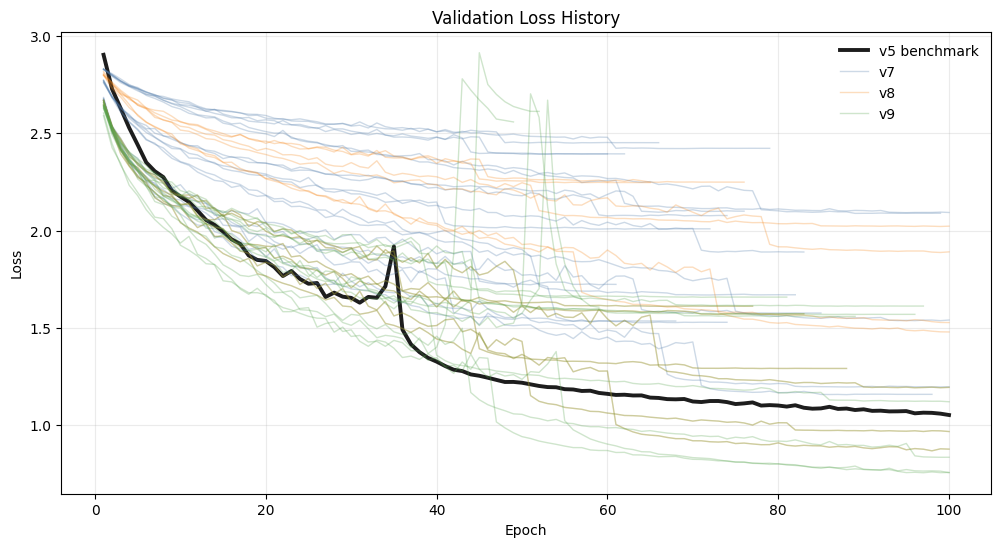

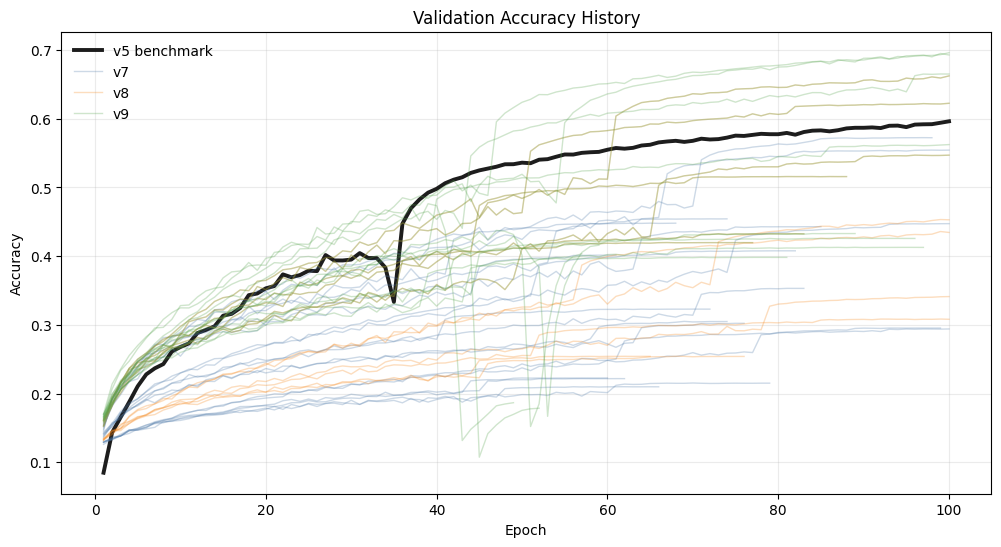

In [103]:
def plot_history_metric(metric, ylabel, better="lower"):
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = {"v7": "#4c78a8", "v8": "#f58518", "v9": "#54a24b", "v5": "#111111"}
    for _, run in summary_df.sort_values(["version", "model_name"]).iterrows():
        data = epoch_df.loc[epoch_df["run_id"].eq(run["run_id"])]
        if data.empty or metric not in data:
            continue
        is_benchmark = run["version"] == BENCHMARK_VERSION
        ax.plot(
            data["epoch"],
            data[metric],
            color=colors.get(run["version"], "#999999"),
            alpha=0.95 if is_benchmark else 0.28,
            linewidth=2.8 if is_benchmark else 1.0,
            label="v5 benchmark" if is_benchmark else run["version"],
        )
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), frameon=False)
    ax.set_title(f"Validation {ylabel} History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    return fig, ax

plot_history_metric("val_loss", "Loss")
plot_history_metric("val_accuracy", "Accuracy", better="higher")
plt.show()



## Test Metrics by Configuration

The vertical dashed lines are v5 benchmark values. Points left of the loss line or above the accuracy line improve on v5 for that metric.


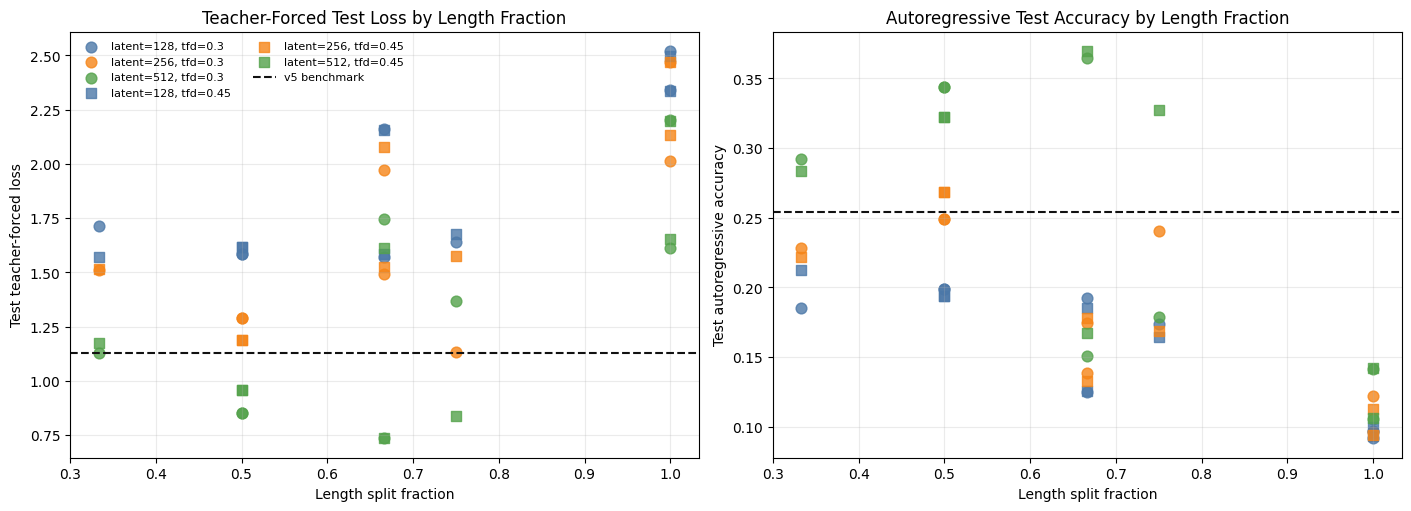

In [104]:
plot_df = summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])].copy()
plot_df["length_label"] = plot_df["length_group"].astype(str)
plot_df["tfd_label"] = plot_df["teacher_forcing_dropout"].map(lambda x: f"tfd={x:g}" if pd.notna(x) else "tfd=?")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
markers = {0.3: "o", 0.45: "s"}
colors = {128: "#4c78a8", 256: "#f58518", 512: "#54a24b"}

for tfd, tfd_df in plot_df.groupby("teacher_forcing_dropout", dropna=False):
    for latent, latent_df in tfd_df.groupby("latent_dim", dropna=False):
        axes[0].scatter(
            latent_df["length_fraction"],
            latent_df["test_tf_loss"],
            label=f"latent={latent}, tfd={tfd:g}",
            marker=markers.get(tfd, "x"),
            color=colors.get(latent, "#999999"),
            alpha=0.8,
            s=60,
        )
        axes[1].scatter(
            latent_df["length_fraction"],
            latent_df["test_ar_accuracy"],
            marker=markers.get(tfd, "x"),
            color=colors.get(latent, "#999999"),
            alpha=0.8,
            s=60,
        )

axes[0].axhline(benchmark["test_tf_loss"], color="#111111", linestyle="--", linewidth=1.5, label="v5 benchmark")
axes[1].axhline(benchmark["test_ar_accuracy"], color="#111111", linestyle="--", linewidth=1.5, label="v5 benchmark")
axes[0].set_title("Teacher-Forced Test Loss by Length Fraction")
axes[1].set_title("Autoregressive Test Accuracy by Length Fraction")
for ax in axes:
    ax.set_xlabel("Length split fraction")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Test teacher-forced loss")
axes[1].set_ylabel("Test autoregressive accuracy")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, frameon=False, fontsize=8, ncols=2)
plt.show()



## Error Pattern 1: Length Split

This aggregates deltas by version and length split. It is useful for spotting whether errors concentrate on longer sequence buckets.


In [105]:
length_summary = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])]
    .groupby(["version", "length_group", "length_fraction"], dropna=False)
    .agg(
        runs=("run_id", "count"),
        mean_tf_loss_delta=("delta_vs_v5_test_tf_loss", "mean"),
        best_tf_loss_delta=("delta_vs_v5_test_tf_loss", "min"),
        mean_tf_accuracy_delta=("delta_vs_v5_test_tf_accuracy", "mean"),
        best_tf_accuracy_delta=("delta_vs_v5_test_tf_accuracy", "max"),
        mean_ar_loss_delta=("delta_vs_v5_test_ar_loss", "mean"),
        best_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "max"),
        mean_generalization_gap=("loss_generalization_gap_final", "mean"),
    )
    .reset_index()
    .sort_values(["version", "length_fraction"])
)
length_summary



,version,length_group,length_fraction,runs,mean_tf_loss_delta,best_tf_loss_delta,mean_tf_accuracy_delta,best_tf_accuracy_delta,mean_ar_loss_delta,best_ar_accuracy_delta,mean_generalization_gap
0,v7,1/3,0.333333,6,0.305310,-0.000242,-0.090176,0.007446,-0.250534,0.038601,0.339218
1,v7,2/3,0.666667,6,0.823070,0.482242,-0.241498,-0.149007,-0.200722,-0.086653,0.276791
2,v7,3/3,1.000000,6,1.261799,1.065433,-0.360170,-0.311413,-0.232676,-0.147746,0.190277
3,v8,1/2,0.500000,6,0.118460,-0.276622,-0.035322,0.092137,-0.162786,0.090316,0.197905
4,v8,2/2,1.000000,6,0.884257,0.479943,-0.265936,-0.159270,-0.100452,-0.111392,0.119943
5,v9,1/2,0.500000,6,0.118460,-0.276622,-0.035322,0.092137,-0.162786,0.090316,0.197905
6,v9,2/3,0.666667,6,0.143072,-0.395645,-0.049201,0.128179,-0.082378,0.115866,0.057508
7,v9,3/4,0.750000,6,0.240588,-0.292755,-0.083677,0.094428,-0.011522,0.073245,0.055723


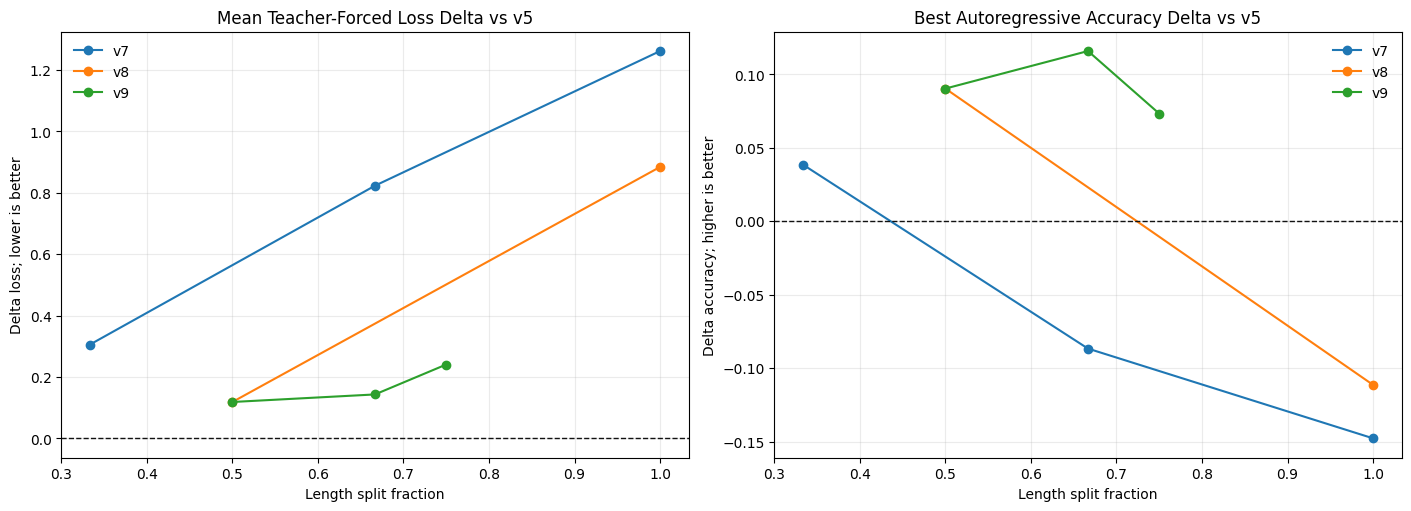

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for version, group in length_summary.groupby("version"):
    axes[0].plot(group["length_fraction"], group["mean_tf_loss_delta"], marker="o", label=version)
    axes[1].plot(group["length_fraction"], group["best_ar_accuracy_delta"], marker="o", label=version)
for ax in axes:
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_xlabel("Length split fraction")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
axes[0].set_title("Mean Teacher-Forced Loss Delta vs v5")
axes[0].set_ylabel("Delta loss; lower is better")
axes[1].set_title("Best Autoregressive Accuracy Delta vs v5")
axes[1].set_ylabel("Delta accuracy; higher is better")
plt.show()



## Error Pattern 2: Latent Dimension and Teacher-Forcing Dropout

This checks whether model capacity or teacher-forcing dropout explains the strongest failures and wins.


In [107]:
config_summary = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])]
    .groupby(["latent_dim", "teacher_forcing_dropout"], dropna=False)
    .agg(
        runs=("run_id", "count"),
        mean_tf_loss=("test_tf_loss", "mean"),
        mean_tf_loss_delta=("delta_vs_v5_test_tf_loss", "mean"),
        best_tf_loss_delta=("delta_vs_v5_test_tf_loss", "min"),
        mean_tf_accuracy_delta=("delta_vs_v5_test_tf_accuracy", "mean"),
        mean_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "mean"),
        best_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "max"),
        mean_val_loss_drift=("val_loss_drift_after_best", "mean"),
        mean_loss_gap=("loss_generalization_gap_final", "mean"),
    )
    .reset_index()
    .sort_values(["latent_dim", "teacher_forcing_dropout"])
)
config_summary



,latent_dim,teacher_forcing_dropout,runs,mean_tf_loss,mean_tf_loss_delta,best_tf_loss_delta,mean_tf_accuracy_delta,mean_ar_accuracy_delta,best_ar_accuracy_delta,mean_val_loss_drift,mean_loss_gap
0,128,0.30,8,1.889651,0.758588,0.440048,-0.223664,-0.095925,-0.054745,0.002248,0.226575
1,128,0.45,8,1.881884,0.750821,0.438933,-0.222603,-0.095307,-0.041564,0.000868,0.198995
2,256,0.30,8,1.646709,0.515646,0.001102,-0.156355,-0.066502,-0.004495,0.019148,0.189512
3,256,0.45,8,1.710999,0.579936,0.059589,-0.175017,-0.073174,0.014830,0.138688,0.154128
4,512,0.30,8,1.312263,0.181200,-0.395645,-0.054394,-0.013601,0.110599,0.151829,0.162139
5,512,0.45,8,1.266134,0.135071,-0.394814,-0.038945,0.001170,0.115866,0.000699,0.145104


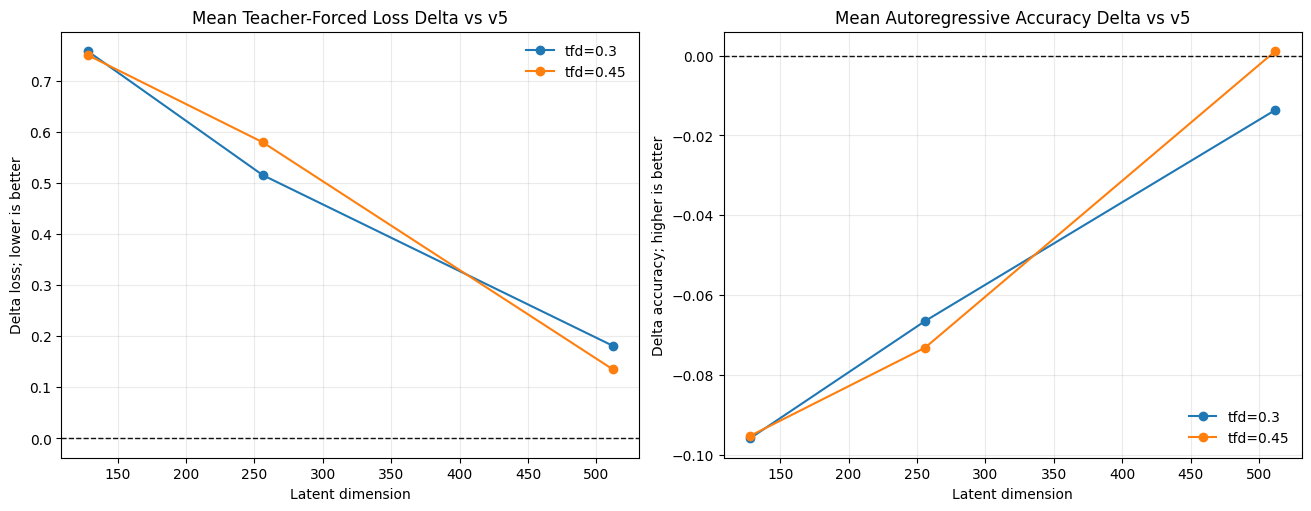

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for tfd, group in config_summary.groupby("teacher_forcing_dropout"):
    axes[0].plot(group["latent_dim"], group["mean_tf_loss_delta"], marker="o", label=f"tfd={tfd:g}")
    axes[1].plot(group["latent_dim"], group["mean_ar_accuracy_delta"], marker="o", label=f"tfd={tfd:g}")
for ax in axes:
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_xlabel("Latent dimension")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
axes[0].set_title("Mean Teacher-Forced Loss Delta vs v5")
axes[0].set_ylabel("Delta loss; lower is better")
axes[1].set_title("Mean Autoregressive Accuracy Delta vs v5")
axes[1].set_ylabel("Delta accuracy; higher is better")
plt.show()



## Error Pattern 3: Validation Drift and Generalization Gap

Large positive validation drift means the final checkpoint is worse than the best validation epoch. Large final loss gap means validation loss remains much higher than training loss.


In [109]:
drift_cols = [
    "version",
    "model_name",
    "length_group",
    "latent_dim",
    "teacher_forcing_dropout",
    "epochs_completed",
    "best_val_loss_epoch",
    "val_loss_drift_after_best",
    "loss_generalization_gap_final",
    "tail_val_loss_std",
    "test_tf_loss",
    "delta_vs_v5_test_tf_loss",
]
summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"]), drift_cols].sort_values(
    ["val_loss_drift_after_best", "loss_generalization_gap_final"], ascending=False
).head(15)



,version,model_name,length_group,latent_dim,teacher_forcing_dropout,epochs_completed,best_val_loss_epoch,val_loss_drift_after_best,loss_generalization_gap_final,tail_val_loss_std,test_tf_loss,delta_vs_v5_test_tf_loss
47,v9,model_ae_length_3_of_4_solubility_latent512_tf...,3/4,512,0.30,49,39,1.192077,-0.008810,0.523569,1.366633,0.235570
46,v9,model_ae_length_3_of_4_solubility_latent256_tf...,3/4,256,0.45,52,42,1.041787,0.005449,0.458394,1.575520,0.444457
39,v9,model_ae_length_2_of_3_solubility_latent256_tf...,2/3,256,0.30,57,47,0.145895,-0.017540,0.433086,1.492183,0.361120
40,v9,model_ae_length_2_of_3_solubility_latent256_tf...,2/3,256,0.45,59,49,0.057656,-0.010378,0.335223,1.526470,0.395407
23,v8,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.30,100,98,0.008785,0.178178,0.006486,0.854441,-0.276622
35,v9,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.30,100,98,0.008785,0.178178,0.006486,0.854441,-0.276622
7,v7,model_ae_length_2_of_3_solubility_latent128_tf...,2/3,128,0.30,76,66,0.005311,0.303035,0.002804,2.161547,1.030484
19,v8,model_ae_length_1_of_2_solubility_latent128_tf...,1/2,128,0.30,83,73,0.003314,0.263916,0.000524,1.584495,0.453432
31,v9,model_ae_length_1_of_2_solubility_latent128_tf...,1/2,128,0.30,83,73,0.003314,0.263916,0.000524,1.584495,0.453432
12,v7,model_ae_length_2_of_3_solubility_latent512_tf...,2/3,512,0.45,100,99,0.003244,0.267555,0.006012,1.613305,0.482242


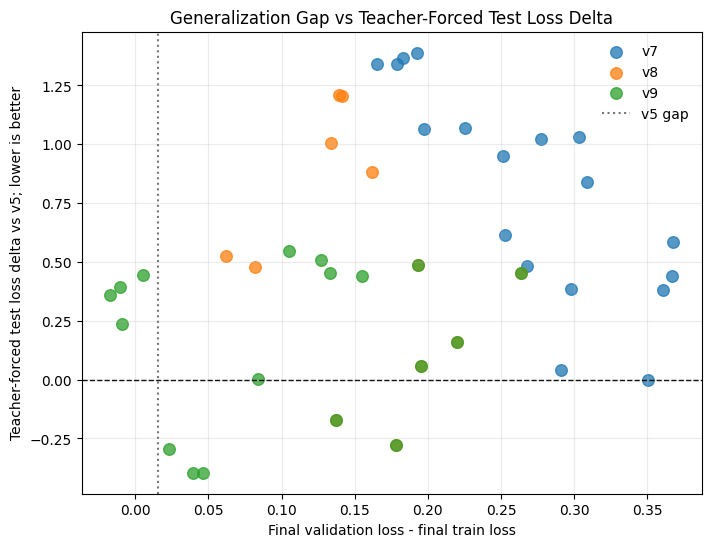

In [110]:
fig, ax = plt.subplots(figsize=(8, 6))
for version, group in summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])].groupby("version"):
    ax.scatter(
        group["loss_generalization_gap_final"],
        group["delta_vs_v5_test_tf_loss"],
        s=70,
        alpha=0.75,
        label=version,
    )
ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
ax.axvline(benchmark["loss_generalization_gap_final"], color="#777777", linestyle=":", linewidth=1.5, label="v5 gap")
ax.set_title("Generalization Gap vs Teacher-Forced Test Loss Delta")
ax.set_xlabel("Final validation loss - final train loss")
ax.set_ylabel("Teacher-forced test loss delta vs v5; lower is better")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.show()



## Potential Duplicate or Repeated Results

This flags checkpoints with identical test metrics. These may be intentional reruns, copied evaluations, or evidence that two versions point to the same checkpoint family.


In [111]:
duplicate_metric_cols = ["test_tf_loss", "test_ar_loss", "test_tf_accuracy", "test_ar_accuracy"]
duplicates = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])]
    .assign(metric_signature=lambda df: df[duplicate_metric_cols].round(6).astype(str).agg("|".join, axis=1))
)
duplicate_groups = duplicates.groupby("metric_signature").filter(lambda g: len(g) > 1)
duplicate_groups[["version", "model_name", *duplicate_metric_cols]].sort_values(duplicate_metric_cols)



,version,model_name,test_tf_loss,test_ar_loss,test_tf_accuracy,test_ar_accuracy
23,v8,model_ae_length_1_of_2_solubility_latent512_tf...,0.854441,3.314992,0.673997,0.344088
35,v9,model_ae_length_1_of_2_solubility_latent512_tf...,0.854441,3.314992,0.673997,0.344088
24,v8,model_ae_length_1_of_2_solubility_latent512_tf...,0.958431,3.045857,0.638494,0.321934
36,v9,model_ae_length_1_of_2_solubility_latent512_tf...,0.958431,3.045857,0.638494,0.321934
22,v8,model_ae_length_1_of_2_solubility_latent256_tf...,1.190652,3.179304,0.562369,0.268602
34,v9,model_ae_length_1_of_2_solubility_latent256_tf...,1.190652,3.179304,0.562369,0.268602
21,v8,model_ae_length_1_of_2_solubility_latent256_tf...,1.291442,3.178959,0.528888,0.249277
33,v9,model_ae_length_1_of_2_solubility_latent256_tf...,1.291442,3.178959,0.528888,0.249277
19,v8,model_ae_length_1_of_2_solubility_latent128_tf...,1.584495,3.263140,0.444430,0.199027
31,v9,model_ae_length_1_of_2_solubility_latent128_tf...,1.584495,3.263140,0.444430,0.199027


## Generated Takeaways

This cell prints a compact interpretation from the loaded metrics. Re-run it after adding histories or refreshing the results CSV.


In [112]:
def fmt_delta(value, metric_type):
    if pd.isna(value):
        return "NA"
    sign = "+" if value >= 0 else ""
    if metric_type == "accuracy":
        return f"{sign}{value:.4f}"
    return f"{sign}{value:.4f}"

candidate_df = summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])].copy()
best_tf = candidate_df.sort_values("test_tf_loss").iloc[0]
best_ar = candidate_df.sort_values("test_ar_accuracy", ascending=False).iloc[0]
worst_tf = candidate_df.sort_values("test_tf_loss", ascending=False).iloc[0]
by_version = candidate_df.groupby("version").agg(
    runs=("run_id", "count"),
    best_tf_loss_delta=("delta_vs_v5_test_tf_loss", "min"),
    best_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "max"),
    median_tf_loss_delta=("delta_vs_v5_test_tf_loss", "median"),
    median_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "median"),
)

print("Benchmark v5:")
print(f"  TF loss={benchmark['test_tf_loss']:.4f}, TF accuracy={benchmark['test_tf_accuracy']:.4f}")
print(f"  AR loss={benchmark['test_ar_loss']:.4f}, AR accuracy={benchmark['test_ar_accuracy']:.4f}")
print()
print("Best teacher-forced loss among v7-v9:")
print(f"  {best_tf['version']} {best_tf['model_name']}")
print(f"  TF loss={best_tf['test_tf_loss']:.4f} ({fmt_delta(best_tf['delta_vs_v5_test_tf_loss'], 'loss')} vs v5)")
print(f"  AR accuracy={best_tf['test_ar_accuracy']:.4f} ({fmt_delta(best_tf['delta_vs_v5_test_ar_accuracy'], 'accuracy')} vs v5)")
print()
print("Best autoregressive accuracy among v7-v9:")
print(f"  {best_ar['version']} {best_ar['model_name']}")
print(f"  AR accuracy={best_ar['test_ar_accuracy']:.4f} ({fmt_delta(best_ar['delta_vs_v5_test_ar_accuracy'], 'accuracy')} vs v5)")
print(f"  TF loss={best_ar['test_tf_loss']:.4f} ({fmt_delta(best_ar['delta_vs_v5_test_tf_loss'], 'loss')} vs v5)")
print()
print("Worst teacher-forced loss among v7-v9:")
print(f"  {worst_tf['version']} {worst_tf['model_name']}")
print(f"  TF loss={worst_tf['test_tf_loss']:.4f} ({fmt_delta(worst_tf['delta_vs_v5_test_tf_loss'], 'loss')} vs v5)")
print()
print("By-version summary:")
display(by_version)



Benchmark v5:
  TF loss=1.1311, TF accuracy=0.5819
  AR loss=3.3443, AR accuracy=0.2538

Best teacher-forced loss among v7-v9:
  v9 model_ae_length_2_of_3_solubility_latent512_tfd0p3
  TF loss=0.7354 (-0.3956 vs v5)
  AR accuracy=0.3644 (+0.1106 vs v5)

Best autoregressive accuracy among v7-v9:
  v9 model_ae_length_2_of_3_solubility_latent512_tfd0p45
  AR accuracy=0.3696 (+0.1159 vs v5)
  TF loss=0.7362 (-0.3948 vs v5)

Worst teacher-forced loss among v7-v9:
  v7 model_ae_length_3_of_3_solubility_latent128_tfd0p3
  TF loss=2.5204 (+1.3893 vs v5)

By-version summary:


,runs,best_tf_loss_delta,best_ar_accuracy_delta,median_tf_loss_delta,median_ar_accuracy_delta
version,,,,,
v7,18,-0.000242,0.038601,0.894374,-0.118235
v8,12,-0.276622,0.090316,0.483279,-0.085731
v9,18,-0.395645,0.115866,0.298345,-0.057408


## Suggested Follow-Up Checks

- If a checkpoint beats v5 on teacher-forced loss but not autoregressive accuracy, inspect free-running decoded sequences for compounding decoder errors.
- If longer length splits have worse deltas, run per-sequence reconstruction analysis stratified by target length once prediction CSVs are available.
- If final validation drift is large, compare the saved checkpoint policy to the best-validation epoch; the test metric may reflect the final epoch rather than the best epoch.
- If duplicate metric signatures are unexpected, verify the checkpoint paths used by the evaluation script before treating those runs as independent evidence.


## Analysis Takeaways

The v5 benchmark has teacher-forced loss `1.1311`, teacher-forced accuracy `0.5819`, autoregressive loss `3.3443`, and autoregressive accuracy `0.2538`.

The strongest overall results are from v9 with latent dimension `512`. The best teacher-forced loss is `v9/model_ae_length_2_of_3_solubility_latent512_tfd0p3`, with teacher-forced loss `0.7354` (`-0.3956` vs v5), teacher-forced accuracy `0.7090` (`+0.1271`), and autoregressive accuracy `0.3644` (`+0.1106`). The best autoregressive accuracy is `v9/model_ae_length_2_of_3_solubility_latent512_tfd0p45`, with autoregressive accuracy `0.3696` (`+0.1159`) and nearly identical teacher-forced loss `0.7362` (`-0.3948`).

Version-level performance improves from v7 to v8 to v9. v7 has only one checkpoint that beats v5 on teacher-forced loss and two that beat v5 on autoregressive accuracy. v8 improves but is still mixed. v9 has five checkpoints that beat v5 on teacher-forced loss and six that beat v5 on autoregressive accuracy, making it the strongest checkpoint family.

Most of the useful improvement comes from latent dimension `512`. Latent `128` and `256` generally remain worse than v5 on accuracy, especially on longer length splits. Length remains a major error factor: v7 degrades strongly from `1/3` to `3/3`, v8 degrades at `2/2`, and v9 handles longer splits better, especially `2/3` and `3/4` with latent `512`.

The `length_1_of_2` checkpoints in v8 and v9 have identical test metrics, so those should not be interpreted as independent results unless that reuse was intentional. The next useful analysis is per-sequence reconstruction error for the two v9 latent512 candidates, stratified by sequence length, amino acid class, and length mismatch or early-stop behavior.


## V9 Dataset Size Split Performance

From this point on, the analysis focuses only on v9. The v9 checkpoint names encode three dataset/length split groups: `1/2`, `2/3`, and `3/4`. The summary below compares each split using both average performance across all latent/dropout settings and the best checkpoint within that split.

Interpretation: lower teacher-forced loss is better; higher autoregressive accuracy is better. Bars show the split average, and points show the best checkpoint in that split.


In [113]:
v9_df = summary_df.loc[summary_df["version"].eq("v9")].copy()
v9_df["split_label"] = v9_df["length_group"]

v9_split_summary = (
    v9_df.groupby(["split_label", "length_fraction"], dropna=False)
    .agg(
        runs=("run_id", "count"),
        mean_tf_loss=("test_tf_loss", "mean"),
        best_tf_loss=("test_tf_loss", "min"),
        mean_tf_accuracy=("test_tf_accuracy", "mean"),
        best_tf_accuracy=("test_tf_accuracy", "max"),
        mean_ar_loss=("test_ar_loss", "mean"),
        best_ar_loss=("test_ar_loss", "min"),
        mean_ar_accuracy=("test_ar_accuracy", "mean"),
        best_ar_accuracy=("test_ar_accuracy", "max"),
    )
    .reset_index()
    .sort_values("length_fraction")
)

v9_split_summary



,split_label,length_fraction,runs,mean_tf_loss,best_tf_loss,mean_tf_accuracy,best_tf_accuracy,mean_ar_loss,best_ar_loss,mean_ar_accuracy,best_ar_accuracy
0,1/2,0.500000,6,1.249523,0.854441,0.546538,0.673997,3.181555,3.045857,0.262771,0.344088
1,2/3,0.666667,6,1.274135,0.735418,0.532659,0.710039,3.261963,3.184764,0.243991,0.369638
2,3/4,0.750000,6,1.371651,0.838308,0.498183,0.676288,3.332819,3.197613,0.209016,0.327017


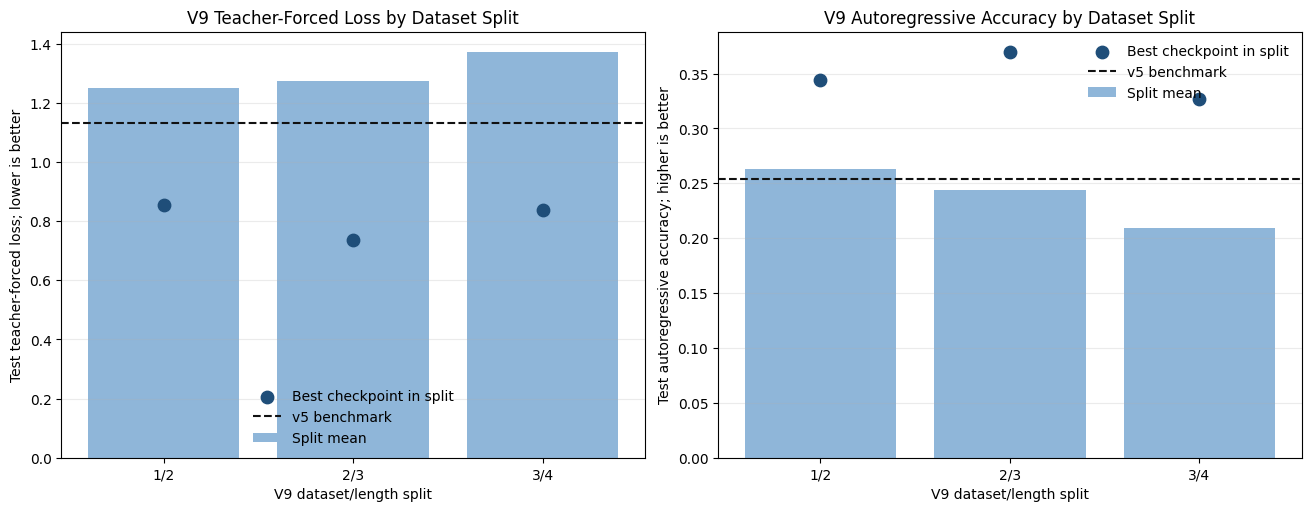

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

x = range(len(v9_split_summary))
labels = v9_split_summary["split_label"].tolist()
bar_color = "#8fb6d9"
best_color = "#1f4e79"
benchmark_color = "#111111"

axes[0].bar(x, v9_split_summary["mean_tf_loss"], color=bar_color, label="Split mean")
axes[0].scatter(x, v9_split_summary["best_tf_loss"], color=best_color, s=80, zorder=3, label="Best checkpoint in split")
axes[0].axhline(benchmark["test_tf_loss"], color=benchmark_color, linestyle="--", linewidth=1.5, label="v5 benchmark")
axes[0].set_title("V9 Teacher-Forced Loss by Dataset Split")
axes[0].set_ylabel("Test teacher-forced loss; lower is better")

axes[1].bar(x, v9_split_summary["mean_ar_accuracy"], color=bar_color, label="Split mean")
axes[1].scatter(x, v9_split_summary["best_ar_accuracy"], color=best_color, s=80, zorder=3, label="Best checkpoint in split")
axes[1].axhline(benchmark["test_ar_accuracy"], color=benchmark_color, linestyle="--", linewidth=1.5, label="v5 benchmark")
axes[1].set_title("V9 Autoregressive Accuracy by Dataset Split")
axes[1].set_ylabel("Test autoregressive accuracy; higher is better")

for ax in axes:
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_xlabel("V9 dataset/length split")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)

plt.show()



In [115]:
best_v9_tf_split = v9_split_summary.loc[v9_split_summary["best_tf_loss"].idxmin()]
best_v9_ar_split = v9_split_summary.loc[v9_split_summary["best_ar_accuracy"].idxmax()]
mean_v9_tf_split = v9_split_summary.loc[v9_split_summary["mean_tf_loss"].idxmin()]
mean_v9_ar_split = v9_split_summary.loc[v9_split_summary["mean_ar_accuracy"].idxmax()]

print("Best individual checkpoint by teacher-forced loss is in split:", best_v9_tf_split["split_label"])
print(f"  best TF loss={best_v9_tf_split['best_tf_loss']:.4f}")
print("Best individual checkpoint by autoregressive accuracy is in split:", best_v9_ar_split["split_label"])
print(f"  best AR accuracy={best_v9_ar_split['best_ar_accuracy']:.4f}")
print()
print("Best split average by teacher-forced loss is:", mean_v9_tf_split["split_label"])
print(f"  mean TF loss={mean_v9_tf_split['mean_tf_loss']:.4f}")
print("Best split average by autoregressive accuracy is:", mean_v9_ar_split["split_label"])
print(f"  mean AR accuracy={mean_v9_ar_split['mean_ar_accuracy']:.4f}")



Best individual checkpoint by teacher-forced loss is in split: 2/3
  best TF loss=0.7354
Best individual checkpoint by autoregressive accuracy is in split: 2/3
  best AR accuracy=0.3696

Best split average by teacher-forced loss is: 1/2
  mean TF loss=1.2495
Best split average by autoregressive accuracy is: 1/2
  mean AR accuracy=0.2628


### V9 Dataset Split Takeaway

The best individual v9 checkpoints are in the `2/3` split. That split contains both the lowest teacher-forced loss checkpoint and the highest autoregressive accuracy checkpoint, driven by latent dimension `512`.

By split average, `1/2` is slightly better than `2/3`, because the weaker latent `128` and `256` checkpoints pull down the `2/3` average. For model selection, the `2/3` split is the stronger choice because its best latent512 checkpoints clearly outperform the best checkpoints from the other v9 splits.


## V9 2/3 Split Loss Curves

This section isolates the v9 checkpoints trained/evaluated on the `2/3` split and plots loss over epochs for each checkpoint. Solid lines are validation loss and lighter dashed lines are training loss for the same checkpoint.


In [116]:
v9_2of3_runs = (
    summary_df.loc[
        summary_df["version"].eq("v9")
        & summary_df["length_group"].eq("2/3")
    ]
    .sort_values(["latent_dim", "teacher_forcing_dropout"])
    .copy()
)

v9_2of3_epoch_df = epoch_df.loc[epoch_df["run_id"].isin(v9_2of3_runs["run_id"])].copy()
v9_2of3_epoch_df = v9_2of3_epoch_df.merge(
    v9_2of3_runs[["run_id", "latent_dim", "teacher_forcing_dropout", "model_name"]],
    on="run_id",
    how="left",
    suffixes=("", "_run"),
)
v9_2of3_epoch_df["curve_label"] = v9_2of3_epoch_df.apply(
    lambda row: f"latent {int(row['latent_dim'])}, tfd {row['teacher_forcing_dropout']:g}",
    axis=1,
)

v9_2of3_runs[[
    "model_name",
    "latent_dim",
    "teacher_forcing_dropout",
    "epochs_completed",
    "best_val_loss",
    "best_val_loss_epoch",
    "test_tf_loss",
    "test_ar_accuracy",
]]



,model_name,latent_dim,teacher_forcing_dropout,epochs_completed,best_val_loss,best_val_loss_epoch,test_tf_loss,test_ar_accuracy
37,model_ae_length_2_of_3_solubility_latent128_tf...,128,0.30,89,1.556953,79,1.571111,0.192042
38,model_ae_length_2_of_3_solubility_latent128_tf...,128,0.45,96,1.568180,86,1.583381,0.185337
39,model_ae_length_2_of_3_solubility_latent256_tf...,256,0.30,57,1.500889,47,1.492183,0.174671
40,model_ae_length_2_of_3_solubility_latent256_tf...,256,0.45,59,1.548221,49,1.526470,0.177889
41,model_ae_length_2_of_3_solubility_latent512_tf...,512,0.30,100,0.753443,97,0.735418,0.364371
42,model_ae_length_2_of_3_solubility_latent512_tf...,512,0.45,100,0.753699,100,0.736249,0.369638


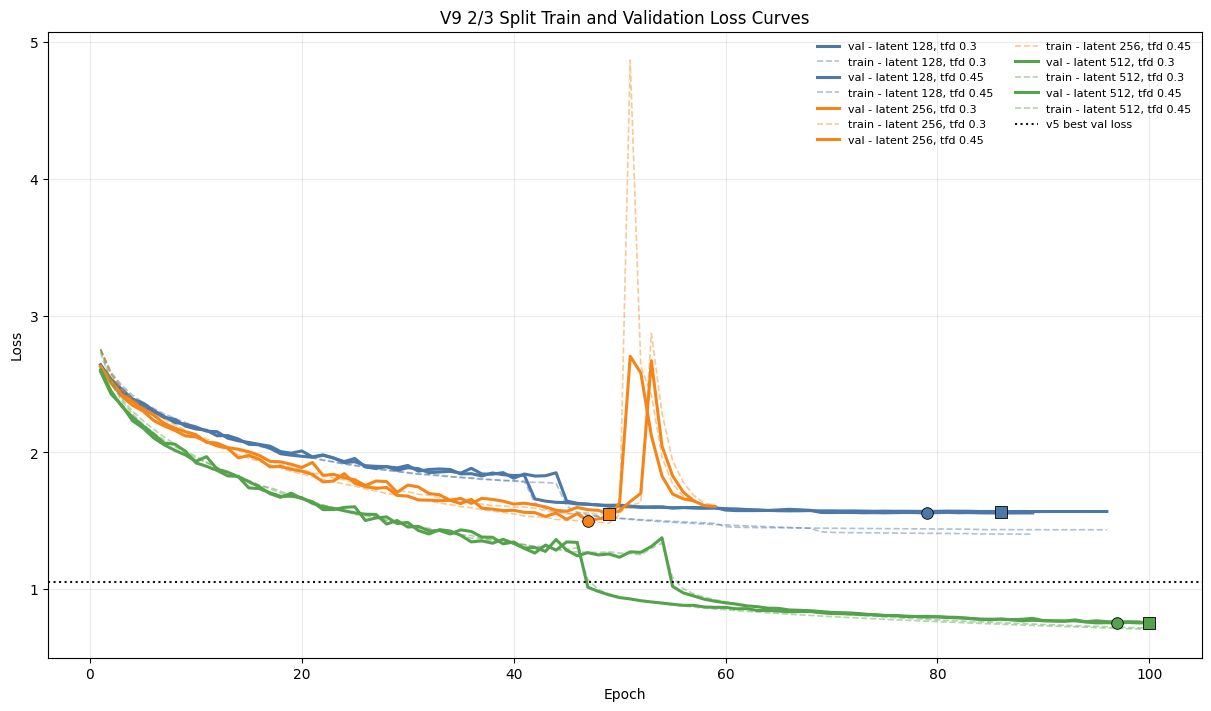

In [117]:
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

colors = {
    128: "#4c78a8",
    256: "#f58518",
    512: "#54a24b",
}
linestyles = {
    0.3: "-",
    0.45: "-",
}
markers = {
    0.3: "o",
    0.45: "s",
}

for _, run in v9_2of3_runs.iterrows():
    data = v9_2of3_epoch_df.loc[v9_2of3_epoch_df["run_id"].eq(run["run_id"])].sort_values("epoch")
    color = colors.get(run["latent_dim"], "#999999")
    label = f"latent {int(run['latent_dim'])}, tfd {run['teacher_forcing_dropout']:g}"

    ax.plot(
        data["epoch"],
        data["val_loss"],
        color=color,
        linestyle=linestyles.get(run["teacher_forcing_dropout"], "-"),
        linewidth=2.2,
        label=f"val - {label}",
    )
    ax.plot(
        data["epoch"],
        data["train_loss"],
        color=color,
        linestyle="--",
        linewidth=1.2,
        alpha=0.45,
        label=f"train - {label}",
    )
    best_epoch = run["best_val_loss_epoch"]
    best_loss = run["best_val_loss"]
    ax.scatter(
        [best_epoch],
        [best_loss],
        color=color,
        marker=markers.get(run["teacher_forcing_dropout"], "o"),
        edgecolor="black",
        linewidth=0.6,
        s=70,
        zorder=4,
    )

ax.axhline(benchmark["best_val_loss"], color="#111111", linestyle=":", linewidth=1.5, label="v5 best val loss")
ax.set_title("V9 2/3 Split Train and Validation Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8, ncols=2)
plt.show()



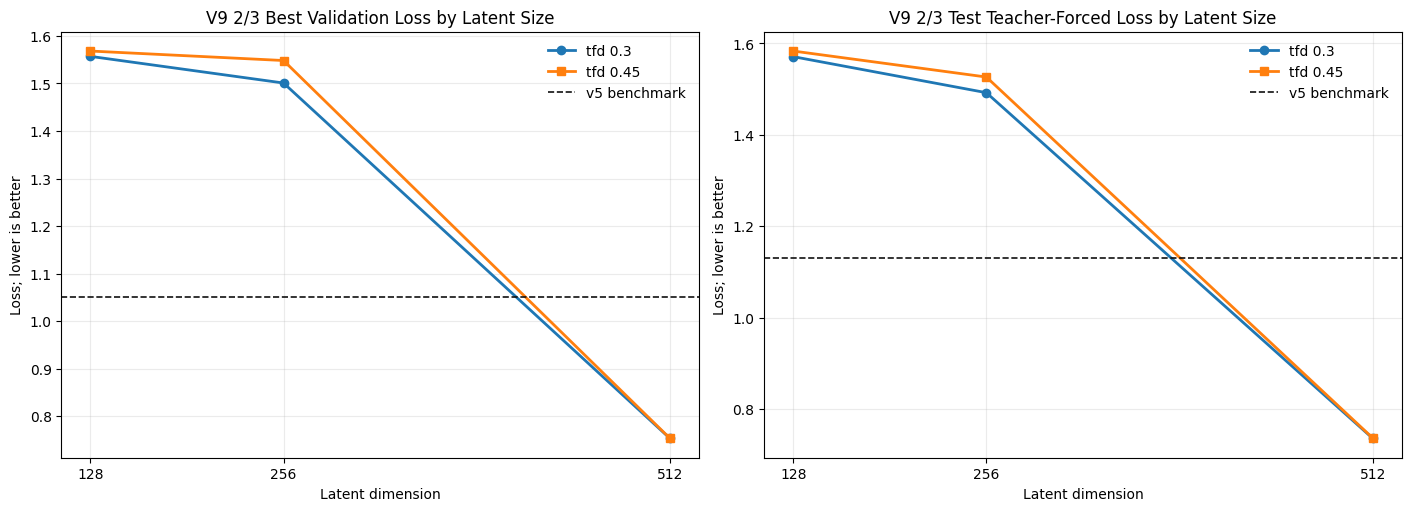

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for tfd, marker in [(0.3, "o"), (0.45, "s")]:
    subset = v9_2of3_runs.loc[v9_2of3_runs["teacher_forcing_dropout"].eq(tfd)].sort_values("latent_dim")
    axes[0].plot(
        subset["latent_dim"],
        subset["best_val_loss"],
        marker=marker,
        linewidth=2,
        label=f"tfd {tfd:g}",
    )
    axes[1].plot(
        subset["latent_dim"],
        subset["test_tf_loss"],
        marker=marker,
        linewidth=2,
        label=f"tfd {tfd:g}",
    )

axes[0].axhline(benchmark["best_val_loss"], color="#111111", linestyle="--", linewidth=1.2, label="v5 benchmark")
axes[1].axhline(benchmark["test_tf_loss"], color="#111111", linestyle="--", linewidth=1.2, label="v5 benchmark")
axes[0].set_title("V9 2/3 Best Validation Loss by Latent Size")
axes[1].set_title("V9 2/3 Test Teacher-Forced Loss by Latent Size")
for ax in axes:
    ax.set_xlabel("Latent dimension")
    ax.set_ylabel("Loss; lower is better")
    ax.set_xticks(sorted(v9_2of3_runs["latent_dim"].unique()))
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()



## V9 2/3 Split Accuracy Curves

This uses the same v9 `2/3` checkpoint subset as the loss curves. Solid lines are validation accuracy and lighter dashed lines are training accuracy for the same checkpoint.


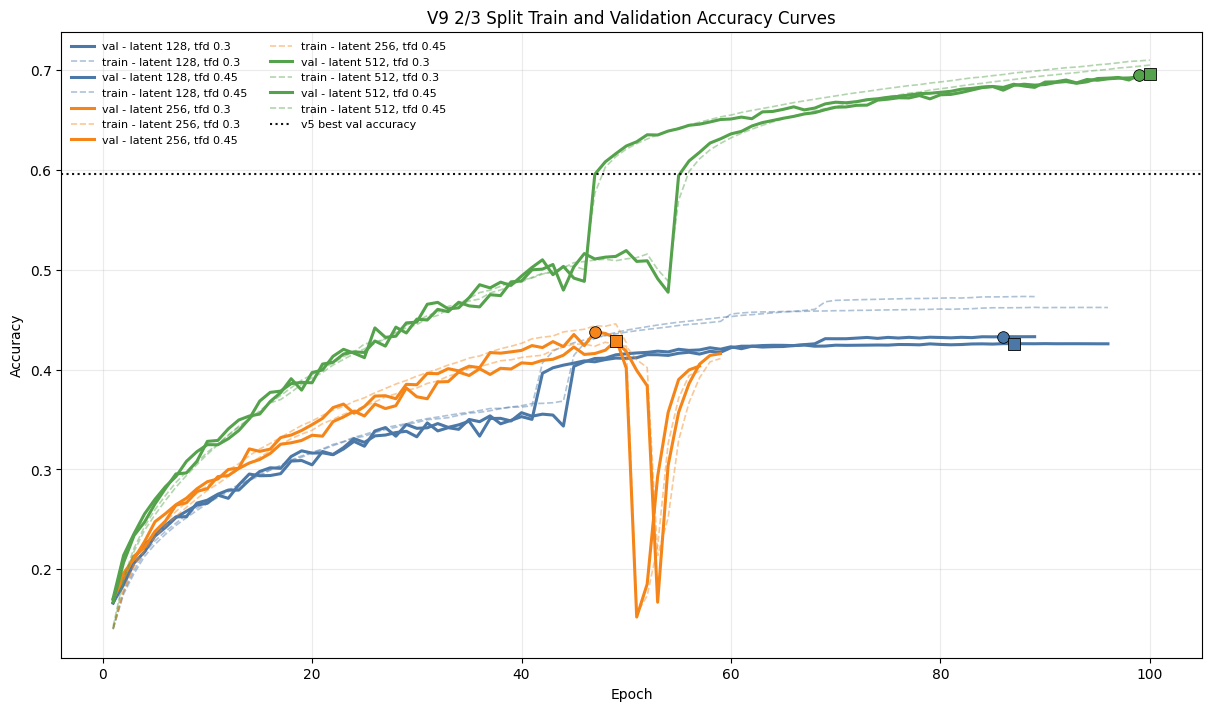

In [119]:
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for _, run in v9_2of3_runs.iterrows():
    data = v9_2of3_epoch_df.loc[v9_2of3_epoch_df["run_id"].eq(run["run_id"])].sort_values("epoch")
    color = colors.get(run["latent_dim"], "#999999")
    label = f"latent {int(run['latent_dim'])}, tfd {run['teacher_forcing_dropout']:g}"

    ax.plot(
        data["epoch"],
        data["val_accuracy"],
        color=color,
        linestyle=linestyles.get(run["teacher_forcing_dropout"], "-"),
        linewidth=2.2,
        label=f"val - {label}",
    )
    ax.plot(
        data["epoch"],
        data["train_accuracy"],
        color=color,
        linestyle="--",
        linewidth=1.2,
        alpha=0.45,
        label=f"train - {label}",
    )
    best_epoch = run["best_val_accuracy_epoch"]
    best_accuracy = run["best_val_accuracy"]
    ax.scatter(
        [best_epoch],
        [best_accuracy],
        color=color,
        marker=markers.get(run["teacher_forcing_dropout"], "o"),
        edgecolor="black",
        linewidth=0.6,
        s=70,
        zorder=4,
    )

ax.axhline(benchmark["best_val_accuracy"], color="#111111", linestyle=":", linewidth=1.5, label="v5 best val accuracy")
ax.set_title("V9 2/3 Split Train and Validation Accuracy Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8, ncols=2)
plt.show()



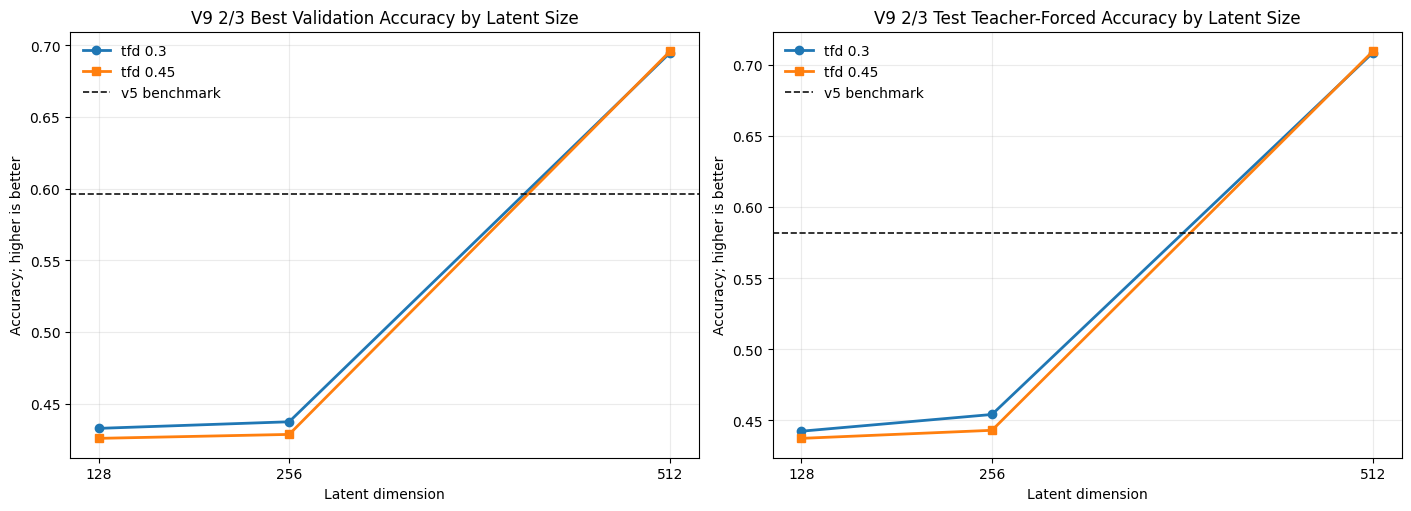

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for tfd, marker in [(0.3, "o"), (0.45, "s")]:
    subset = v9_2of3_runs.loc[v9_2of3_runs["teacher_forcing_dropout"].eq(tfd)].sort_values("latent_dim")
    axes[0].plot(
        subset["latent_dim"],
        subset["best_val_accuracy"],
        marker=marker,
        linewidth=2,
        label=f"tfd {tfd:g}",
    )
    axes[1].plot(
        subset["latent_dim"],
        subset["test_tf_accuracy"],
        marker=marker,
        linewidth=2,
        label=f"tfd {tfd:g}",
    )

axes[0].axhline(benchmark["best_val_accuracy"], color="#111111", linestyle="--", linewidth=1.2, label="v5 benchmark")
axes[1].axhline(benchmark["test_tf_accuracy"], color="#111111", linestyle="--", linewidth=1.2, label="v5 benchmark")
axes[0].set_title("V9 2/3 Best Validation Accuracy by Latent Size")
axes[1].set_title("V9 2/3 Test Teacher-Forced Accuracy by Latent Size")
for ax in axes:
    ax.set_xlabel("Latent dimension")
    ax.set_ylabel("Accuracy; higher is better")
    ax.set_xticks(sorted(v9_2of3_runs["latent_dim"].unique()))
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()



### V9 2/3 Accuracy Curve Takeaway

The accuracy curves mirror the loss curves: latent `512` is the only v9 `2/3` setting that clearly exceeds the v5 benchmark. Latent `128` and `256` improve during training but plateau well below the latent `512` checkpoints.


### V9 2/3 Loss Curve Takeaway

Within the v9 `2/3` split, the latent `512` checkpoints separate clearly from latent `128` and `256`: they reach much lower validation loss and also produce the best test losses. The two latent `512` dropout settings are very close, with `tfd0p3` having the lowest teacher-forced test loss and `tfd0p45` having the best autoregressive accuracy from the earlier comparison.


### V10 2/3 Loss Curve Analysis

The next idea was to see if we could get a better, more stable, checkpoint for a smaller latent vector size of `256` on the `2/3` split. The v10 ran checkpoints on latent vector dimensions `256` and did so on conservative learning rate parameters. Below are the results:

#### V10 Comparison Setup

This section compares the available v10 `2/3` latent256 checkpoint(s) against the v9 `2/3` latent256 runs and the v9 `2/3` latent512 reference runs. The v10 history includes learning-rate and gradient-norm diagnostics, so we can check whether the scheduler actually fired and whether gradient spikes aligned with metric collapse.


In [121]:
def parse_history_metadata(path):
    name = path.name
    version = path.parent.name
    latent_match = re.search(r"latent(\d+)", name)
    tfd_match = re.search(r"tfd(\d+)p(\d+)", name)
    sf_match = re.search(r"sf(\d+)p(\d+)", name)
    return {
        "version": version,
        "run_label": name.removesuffix("_history.json").replace(f"{version}_model_ae_length_2_of_3_solubility_", ""),
        "history_path": str(path.relative_to(PROJECT_ROOT)),
        "latent_dim": int(latent_match.group(1)) if latent_match else None,
        "teacher_forcing_dropout": float(f"{tfd_match.group(1)}.{tfd_match.group(2)}") if tfd_match else None,
        "scheduler_factor_suffix": float(f"{sf_match.group(1)}.{sf_match.group(2)}") if sf_match else None,
    }


def load_history_frame(path):
    with path.open() as f:
        history = json.load(f)
    meta = parse_history_metadata(path)
    hp = history.get("hyperparameters", {})
    epochs = pd.DataFrame(history.get("epochs", []))
    for key, value in meta.items():
        epochs[key] = value
    epochs["learning_rate_config"] = hp.get("learning_rate")
    epochs["lr_patience_config"] = hp.get("lr_patience")
    epochs["scheduler_factor_config"] = hp.get("scheduler_factor")
    return history, meta, epochs


def summarize_history(path):
    history, meta, epochs = load_history_frame(path)
    hp = history.get("hyperparameters", {})
    best_loss = epochs.loc[epochs["val_loss"].idxmin()]
    best_acc = epochs.loc[epochs["val_accuracy"].idxmax()]
    final = epochs.iloc[-1]
    test = history.get("test", {})
    return {
        **meta,
        "epochs": len(epochs),
        "learning_rate": hp.get("learning_rate"),
        "lr_patience": hp.get("lr_patience"),
        "scheduler_factor": hp.get("scheduler_factor"),
        "best_val_loss": best_loss["val_loss"],
        "best_val_loss_epoch": int(best_loss["epoch"]),
        "best_val_accuracy": best_acc["val_accuracy"],
        "best_val_accuracy_epoch": int(best_acc["epoch"]),
        "final_train_loss": final["train_loss"],
        "final_val_loss": final["val_loss"],
        "final_train_accuracy": final["train_accuracy"],
        "final_val_accuracy": final["val_accuracy"],
        "final_loss_gap": final["val_loss"] - final["train_loss"],
        "test_tf_loss": test.get("teacher_forced", {}).get("loss"),
        "test_tf_accuracy": test.get("teacher_forced", {}).get("accuracy"),
        "test_ar_loss": test.get("autoregressive", {}).get("loss"),
        "test_ar_accuracy": test.get("autoregressive", {}).get("accuracy"),
    }

v10_paths = sorted((RESULTS_ROOT / "v10").glob("*length_2_of_3*latent256*_history.json"))
v9_reference_paths = sorted((RESULTS_ROOT / "v9").glob("*length_2_of_3*latent256*_history.json"))
v9_reference_paths += sorted((RESULTS_ROOT / "v9").glob("*length_2_of_3*latent512*_history.json"))
comparison_paths = v10_paths + v9_reference_paths

print(f"Found {len(v10_paths)} v10 history file(s):")
for path in v10_paths:
    print(" -", path.relative_to(PROJECT_ROOT))

v10_histories = {}
comparison_epoch_df = []
for path in comparison_paths:
    history, meta, epochs = load_history_frame(path)
    v10_histories[meta["run_label"]] = history
    comparison_epoch_df.append(epochs)

comparison_epoch_df = pd.concat(comparison_epoch_df, ignore_index=True)
v10_comparison_summary = pd.DataFrame([summarize_history(path) for path in comparison_paths])
v10_comparison_summary = v10_comparison_summary.sort_values(["version", "latent_dim", "teacher_forcing_dropout"]).reset_index(drop=True)
v10_comparison_summary



Found 2 v10 history file(s):
 - Code/results/autoencoder/solubility/v10/v10_model_ae_length_2_of_3_solubility_latent256_tfd0p3_sf0p5_history.json
 - Code/results/autoencoder/solubility/v10/v10_model_ae_length_2_of_3_solubility_latent256_tfd0p45_sf0p5_history.json


,version,run_label,history_path,latent_dim,teacher_forcing_dropout,scheduler_factor_suffix,epochs,learning_rate,lr_patience,scheduler_factor,best_val_loss,best_val_loss_epoch,best_val_accuracy,best_val_accuracy_epoch,final_train_loss,final_val_loss,final_train_accuracy,final_val_accuracy,final_loss_gap,test_tf_loss,test_tf_accuracy,test_ar_loss,test_ar_accuracy
0,v10,latent256_tfd0p3_sf0p5,Code/results/autoencoder/solubility/v10/v10_mo...,256,0.30,0.5,100,0.0003,5,0.5,0.921966,100,0.638502,100,0.851510,0.921966,0.658972,0.638502,0.070456,0.900727,0.656678,3.836204,0.281173
1,v10,latent256_tfd0p45_sf0p5,Code/results/autoencoder/solubility/v10/v10_mo...,256,0.45,0.5,100,0.0003,3,0.5,0.919230,99,0.636530,99,0.863084,0.921346,0.654273,0.635011,0.058261,0.904372,0.653692,4.073071,0.266204
2,v9,latent256_tfd0p3,Code/results/autoencoder/solubility/v9/v9_mode...,256,0.30,NaN,57,0.0010,3,NaN,1.500889,47,0.437520,47,1.664324,1.646785,0.398327,0.403476,-0.017540,1.492183,0.454164,3.427526,0.174671
3,v9,latent256_tfd0p45,Code/results/autoencoder/solubility/v9/v9_mode...,256,0.45,NaN,59,0.0010,3,NaN,1.548221,49,0.428708,49,1.616255,1.605877,0.411042,0.415918,-0.010378,1.526470,0.443019,3.211277,0.177889
4,v9,latent512_tfd0p3,Code/results/autoencoder/solubility/v9/v9_mode...,512,0.30,NaN,100,0.0010,3,NaN,0.753443,97,0.694954,99,0.715840,0.755032,0.704981,0.692756,0.039192,0.735418,0.709003,3.215062,0.364371
5,v9,latent512_tfd0p45,Code/results/autoencoder/solubility/v9/v9_mode...,512,0.45,NaN,100,0.0010,3,NaN,0.753699,100,0.696039,100,0.707730,0.753699,0.709959,0.696039,0.045969,0.736249,0.710039,3.184764,0.369638


#### Summary Table

The table below compares v10 against the matching v9 latent256 baselines and the v9 latent512 references. The key comparison is v10 latent256 `tfd0p3` versus v9 latent256 `tfd0p3`, because that isolates the same latent size and teacher-forcing dropout while changing the optimizer schedule.


In [122]:
summary_cols = [
    "version",
    "run_label",
    "epochs",
    "latent_dim",
    "teacher_forcing_dropout",
    "learning_rate",
    "lr_patience",
    "scheduler_factor",
    "best_val_loss",
    "best_val_loss_epoch",
    "best_val_accuracy",
    "best_val_accuracy_epoch",
    "test_tf_loss",
    "test_tf_accuracy",
    "test_ar_loss",
    "test_ar_accuracy",
]

v10_comparison_summary[summary_cols]



,version,run_label,epochs,latent_dim,teacher_forcing_dropout,learning_rate,lr_patience,scheduler_factor,best_val_loss,best_val_loss_epoch,best_val_accuracy,best_val_accuracy_epoch,test_tf_loss,test_tf_accuracy,test_ar_loss,test_ar_accuracy
0,v10,latent256_tfd0p3_sf0p5,100,256,0.30,0.0003,5,0.5,0.921966,100,0.638502,100,0.900727,0.656678,3.836204,0.281173
1,v10,latent256_tfd0p45_sf0p5,100,256,0.45,0.0003,3,0.5,0.919230,99,0.636530,99,0.904372,0.653692,4.073071,0.266204
2,v9,latent256_tfd0p3,57,256,0.30,0.0010,3,NaN,1.500889,47,0.437520,47,1.492183,0.454164,3.427526,0.174671
3,v9,latent256_tfd0p45,59,256,0.45,0.0010,3,NaN,1.548221,49,0.428708,49,1.526470,0.443019,3.211277,0.177889
4,v9,latent512_tfd0p3,100,512,0.30,0.0010,3,NaN,0.753443,97,0.694954,99,0.735418,0.709003,3.215062,0.364371
5,v9,latent512_tfd0p45,100,512,0.45,0.0010,3,NaN,0.753699,100,0.696039,100,0.736249,0.710039,3.184764,0.369638


In [123]:
baseline = v10_comparison_summary.loc[
    (v10_comparison_summary["version"].eq("v9"))
    & (v10_comparison_summary["latent_dim"].eq(256))
    & (v10_comparison_summary["teacher_forcing_dropout"].eq(0.3))
].iloc[0]

v10_completed = v10_comparison_summary.loc[v10_comparison_summary["version"].eq("v10")].copy()
for metric in ["best_val_loss", "best_val_accuracy", "test_tf_loss", "test_tf_accuracy", "test_ar_loss", "test_ar_accuracy"]:
    v10_completed[f"delta_vs_v9_256_tfd0p3_{metric}"] = v10_completed[metric] - baseline[metric]

v10_completed[[
    "run_label",
    "best_val_loss",
    "delta_vs_v9_256_tfd0p3_best_val_loss",
    "best_val_accuracy",
    "delta_vs_v9_256_tfd0p3_best_val_accuracy",
    "test_tf_loss",
    "delta_vs_v9_256_tfd0p3_test_tf_loss",
    "test_tf_accuracy",
    "delta_vs_v9_256_tfd0p3_test_tf_accuracy",
    "test_ar_accuracy",
    "delta_vs_v9_256_tfd0p3_test_ar_accuracy",
]]



,run_label,best_val_loss,delta_vs_v9_256_tfd0p3_best_val_loss,best_val_accuracy,delta_vs_v9_256_tfd0p3_best_val_accuracy,test_tf_loss,delta_vs_v9_256_tfd0p3_test_tf_loss,test_tf_accuracy,delta_vs_v9_256_tfd0p3_test_tf_accuracy,test_ar_accuracy,delta_vs_v9_256_tfd0p3_test_ar_accuracy
0,latent256_tfd0p3_sf0p5,0.921966,-0.578923,0.638502,0.200982,0.900727,-0.591456,0.656678,0.202513,0.281173,0.106502
1,latent256_tfd0p45_sf0p5,0.919230,-0.581659,0.636530,0.199009,0.904372,-0.587811,0.653692,0.199528,0.266204,0.091533


#### Training Curves

These plots show why v10 is different: the v10 latent256 run avoids the epoch-50 collapse seen in v9 latent256 and continues improving through epoch 100. The v9 latent512 lines remain the stronger upper reference, but v10 greatly narrows the gap.


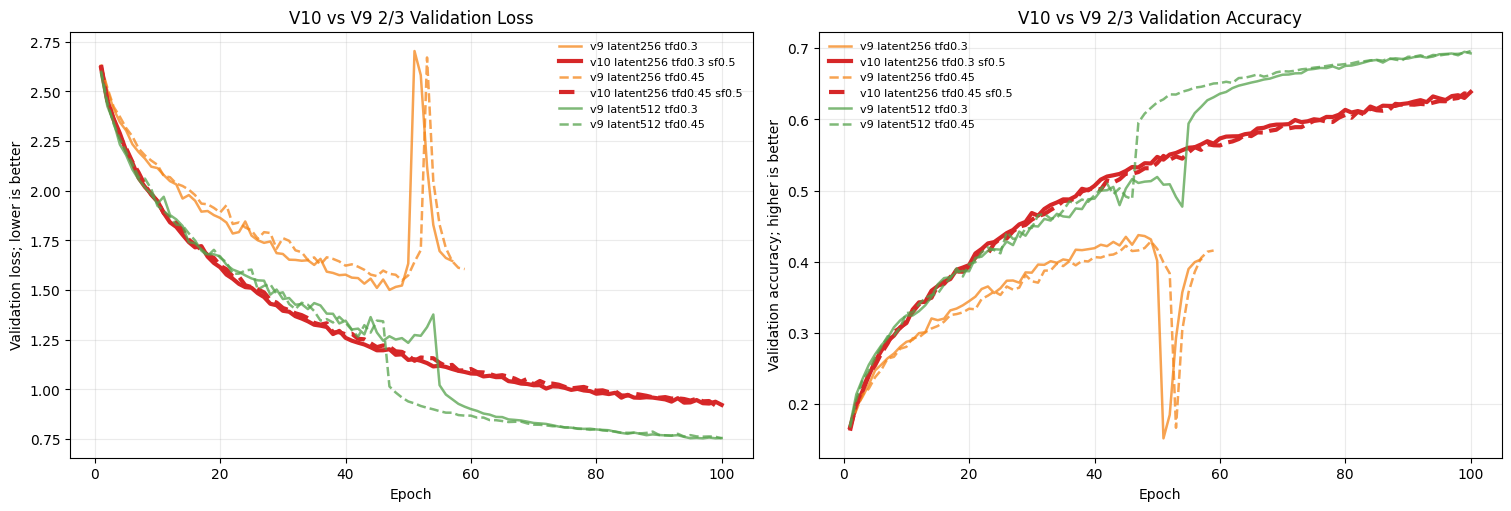

In [124]:
plot_runs = v10_comparison_summary.copy()
plot_runs["plot_label"] = plot_runs.apply(
    lambda row: f"{row['version']} latent{int(row['latent_dim'])} tfd{row['teacher_forcing_dropout']:g}"
    + (f" sf{row['scheduler_factor']:g}" if pd.notna(row["scheduler_factor"]) else ""),
    axis=1,
)
label_map = dict(zip(plot_runs["run_label"], plot_runs["plot_label"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for run_label, data in comparison_epoch_df.groupby("run_label"):
    meta = plot_runs.loc[plot_runs["run_label"].eq(run_label)].iloc[0]
    is_v10 = meta["version"] == "v10"
    is_512 = meta["latent_dim"] == 512
    color = "#d62728" if is_v10 else ("#54a24b" if is_512 else "#f58518")
    linestyle = "-" if meta["teacher_forcing_dropout"] == 0.3 else "--"
    linewidth = 3.0 if is_v10 else 1.8
    alpha = 1.0 if is_v10 else 0.75
    label = label_map[run_label]

    axes[0].plot(data["epoch"], data["val_loss"], color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)
    axes[1].plot(data["epoch"], data["val_accuracy"], color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)

axes[0].set_title("V10 vs V9 2/3 Validation Loss")
axes[0].set_ylabel("Validation loss; lower is better")
axes[1].set_title("V10 vs V9 2/3 Validation Accuracy")
axes[1].set_ylabel("Validation accuracy; higher is better")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
plt.show()



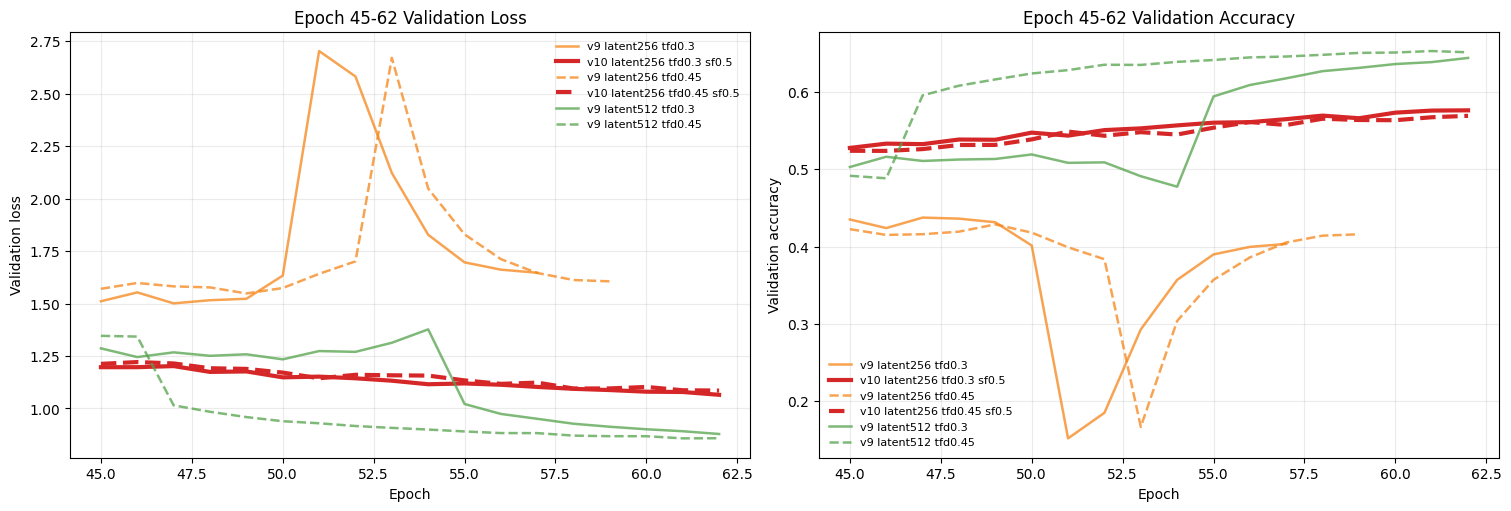

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
window = comparison_epoch_df.loc[comparison_epoch_df["epoch"].between(45, 62)].copy()
for run_label, data in window.groupby("run_label"):
    meta = plot_runs.loc[plot_runs["run_label"].eq(run_label)].iloc[0]
    is_v10 = meta["version"] == "v10"
    is_512 = meta["latent_dim"] == 512
    color = "#d62728" if is_v10 else ("#54a24b" if is_512 else "#f58518")
    linestyle = "-" if meta["teacher_forcing_dropout"] == 0.3 else "--"
    linewidth = 3.0 if is_v10 else 1.8
    alpha = 1.0 if is_v10 else 0.75
    label = label_map[run_label]
    axes[0].plot(data["epoch"], data["val_loss"], color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)
    axes[1].plot(data["epoch"], data["val_accuracy"], color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)

axes[0].set_title("Epoch 45-62 Validation Loss")
axes[0].set_ylabel("Validation loss")
axes[1].set_title("Epoch 45-62 Validation Accuracy")
axes[1].set_ylabel("Validation accuracy")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
plt.show()



#### Test and Best-Validation Metrics

These bar charts summarize the practical tradeoff. v10 latent256 beats the old v9 latent256 runs by a large margin and beats v5 on teacher-forced metrics, but v9 latent512 still has the best overall reconstruction quality.


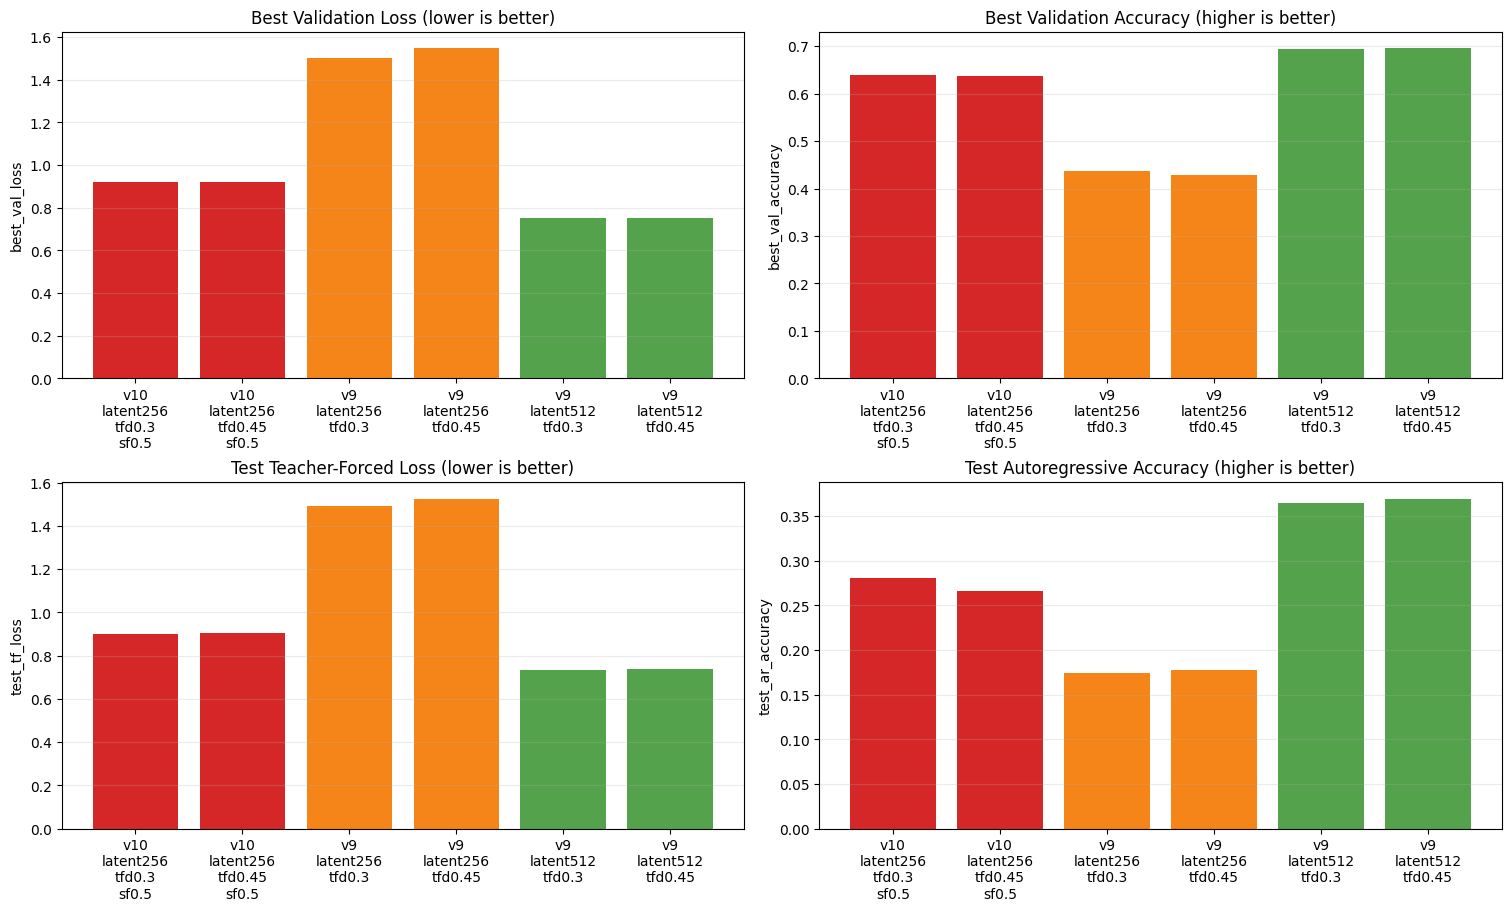

In [126]:
bar_df = v10_comparison_summary.copy()
bar_df["plot_label"] = bar_df.apply(
    lambda row: f"{row['version']}\nlatent{int(row['latent_dim'])}\ntfd{row['teacher_forcing_dropout']:g}"
    + (f"\nsf{row['scheduler_factor']:g}" if pd.notna(row["scheduler_factor"]) else ""),
    axis=1,
)
bar_df = bar_df.sort_values(["latent_dim", "version", "teacher_forcing_dropout"])

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
metrics = [
    ("best_val_loss", "Best Validation Loss", "lower"),
    ("best_val_accuracy", "Best Validation Accuracy", "higher"),
    ("test_tf_loss", "Test Teacher-Forced Loss", "lower"),
    ("test_ar_accuracy", "Test Autoregressive Accuracy", "higher"),
]
colors = ["#d62728" if version == "v10" else ("#54a24b" if latent == 512 else "#f58518") for version, latent in zip(bar_df["version"], bar_df["latent_dim"])]

for ax, (metric, title, direction) in zip(axes.ravel(), metrics):
    ax.bar(bar_df["plot_label"], bar_df[metric], color=colors)
    ax.set_title(f"{title} ({direction} is better)")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", labelrotation=0)
    ax.grid(axis="y", alpha=0.25)
plt.show()



#### V10 LR and Gradient Diagnostics

The v10 run logged learning rate and pre-clip gradient norms. The scheduler did not reduce LR in the completed v10 run, so the improvement is mainly evidence that the lower starting LR avoided the v9 latent256 instability rather than evidence that a later scheduler rescue fixed it.


In [127]:
v10_epoch_df = comparison_epoch_df.loc[comparison_epoch_df["version"].eq("v10")].copy()
if v10_epoch_df.empty:
    print("No v10 epochs available yet.")
else:
    diagnostic_cols = [
        "run_label",
        "epoch",
        "train_loss",
        "val_loss",
        "train_accuracy",
        "val_accuracy",
        "learning_rate",
        "learning_rate_after_scheduler",
        "grad_norm_pre_clip_mean",
        "grad_norm_pre_clip_max",
    ]
    display(v10_epoch_df[diagnostic_cols].tail(20))



,run_label,epoch,train_loss,val_loss,train_accuracy,val_accuracy,learning_rate,learning_rate_after_scheduler,grad_norm_pre_clip_mean,grad_norm_pre_clip_max
180,latent256_tfd0p45_sf0p5,81,0.940908,0.995209,0.622561,0.602341,0.0003,0.0003,3.614144,5.748623
181,latent256_tfd0p45_sf0p5,82,0.936356,0.986048,0.624507,0.610676,0.0003,0.0003,3.608440,6.911918
182,latent256_tfd0p45_sf0p5,83,0.932553,0.991393,0.626138,0.607085,0.0003,0.0003,3.684063,25.802231
183,latent256_tfd0p45_sf0p5,84,0.928757,0.969232,0.627558,0.615420,0.0003,0.0003,3.622230,14.985630
184,latent256_tfd0p45_sf0p5,85,0.923538,0.969180,0.629588,0.612855,0.0003,0.0003,3.623879,8.164413
185,latent256_tfd0p45_sf0p5,86,0.917569,0.978457,0.632082,0.612168,0.0003,0.0003,3.623461,6.868662
186,latent256_tfd0p45_sf0p5,87,0.913562,0.973434,0.633801,0.613503,0.0003,0.0003,3.640710,7.183358
187,latent256_tfd0p45_sf0p5,88,0.909745,0.967788,0.635269,0.621877,0.0003,0.0003,3.635586,5.991198
188,latent256_tfd0p45_sf0p5,89,0.905218,0.959995,0.637165,0.620745,0.0003,0.0003,3.677018,29.191744
189,latent256_tfd0p45_sf0p5,90,0.901739,0.957839,0.638604,0.621036,0.0003,0.0003,3.670466,6.731524


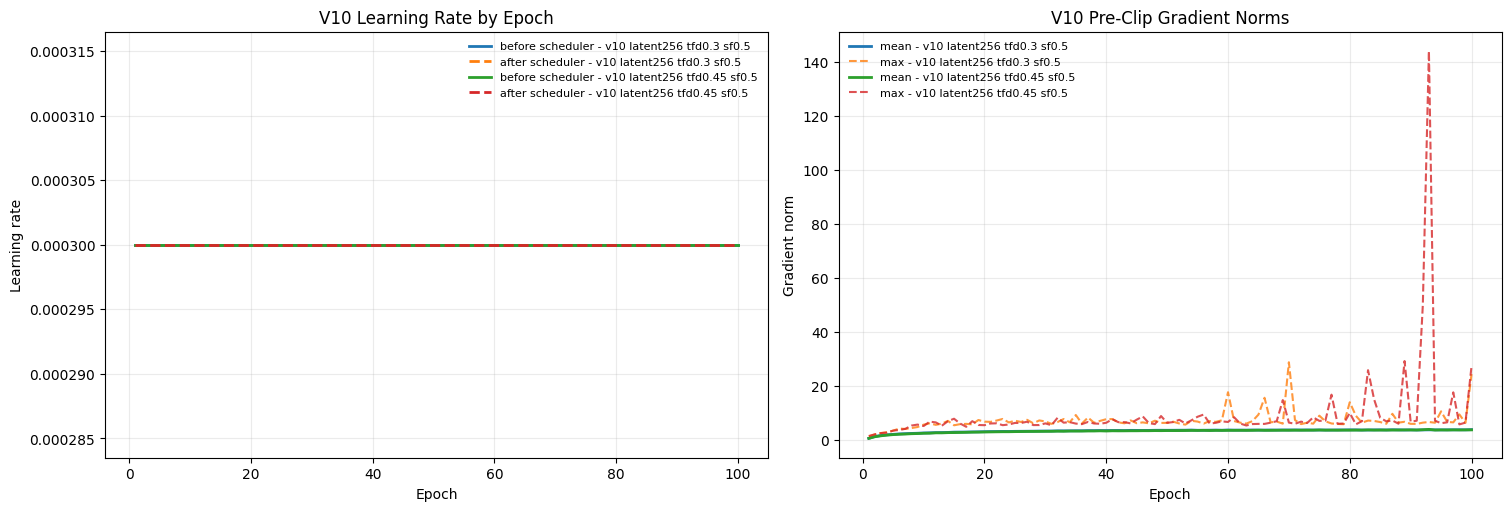

In [128]:
if not v10_epoch_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    for run_label, data in v10_epoch_df.groupby("run_label"):
        label = label_map.get(run_label, run_label)
        axes[0].plot(data["epoch"], data["learning_rate"], label=f"before scheduler - {label}", linewidth=2)
        axes[0].plot(data["epoch"], data["learning_rate_after_scheduler"], linestyle="--", label=f"after scheduler - {label}", linewidth=2)
        axes[1].plot(data["epoch"], data["grad_norm_pre_clip_mean"], label=f"mean - {label}", linewidth=2)
        axes[1].plot(data["epoch"], data["grad_norm_pre_clip_max"], linestyle="--", alpha=0.8, label=f"max - {label}", linewidth=1.5)

    axes[0].set_title("V10 Learning Rate by Epoch")
    axes[0].set_ylabel("Learning rate")
    axes[1].set_title("V10 Pre-Clip Gradient Norms")
    axes[1].set_ylabel("Gradient norm")
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
    plt.show()



#### V10 Takeaway

The available v10 result is a strong positive result for latent256. Compared with the matching v9 latent256 `tfd0p3` run, v10 improves best validation loss from `1.5009` to `0.9220`, best validation accuracy from `0.4375` to `0.6385`, test teacher-forced loss from `1.4922` to `0.9007`, and test autoregressive accuracy from `0.1747` to `0.2812`.

The important diagnostic is that the v10 learning rate stayed at `3e-4` for the whole run. That means the improvement was not caused by the scheduler rescuing the run after collapse. Instead, the lower initial learning rate appears to have prevented the latent256 instability seen in v9. Latent512 still performs better overall, but latent256 is now viable enough to justify additional tuning after the second v10 dropout run completes.


### V11 Teacher-Forcing Dropout Sweep

The v11 runs keep the same architecture target as the completed v10 run: solubility `length_2_of_3`, latent dimension `256`, learning rate `3e-4`, LR patience `3`, and scheduler factor `0.1`. The controlled variable is teacher-forcing dropout: `0.1`, `0.2`, `0.3`, and `0.45`.

This section loads the v11 history JSON files and checks that matching checkpoint files exist, but it only displays tables and plots in the notebook. It does not save figures, CSVs, or analysis artifacts.


In [129]:
def checkpoint_path_from_history(history_path):
    name = history_path.name
    version = history_path.parent.name
    if name.startswith(f"{version}_"):
        name = name[len(version) + 1:]
    checkpoint_name = name.removesuffix("_history.json") + ".pt"
    return CHECKPOINT_ROOT / version / checkpoint_name


def load_v11_run(path):
    with path.open() as f:
        history = json.load(f)
    history_data, meta, epochs = load_history_frame(path)
    checkpoint_path = checkpoint_path_from_history(path)
    hp = history.get("hyperparameters", {})
    test = history.get("test", {})
    ar_val = pd.DataFrame(history.get("autoregressive_val", []))
    best_loss = epochs.loc[epochs["val_loss"].idxmin()]
    best_acc = epochs.loc[epochs["val_accuracy"].idxmax()]
    final = epochs.iloc[-1]

    summary = {
        **meta,
        "checkpoint": str(checkpoint_path.relative_to(PROJECT_ROOT)),
        "checkpoint_exists": checkpoint_path.exists(),
        "checkpoint_size_mb": checkpoint_path.stat().st_size / (1024 * 1024) if checkpoint_path.exists() else math.nan,
        "epochs": len(epochs),
        "learning_rate": hp.get("learning_rate"),
        "lr_patience": hp.get("lr_patience"),
        "scheduler_factor": hp.get("scheduler_factor"),
        "final_train_loss": final["train_loss"],
        "final_train_accuracy": final["train_accuracy"],
        "final_val_loss": final["val_loss"],
        "final_val_accuracy": final["val_accuracy"],
        "best_val_loss": best_loss["val_loss"],
        "best_val_loss_epoch": int(best_loss["epoch"]),
        "best_val_accuracy": best_acc["val_accuracy"],
        "best_val_accuracy_epoch": int(best_acc["epoch"]),
        "test_tf_loss": test.get("teacher_forced", {}).get("loss"),
        "test_tf_accuracy": test.get("teacher_forced", {}).get("accuracy"),
        "test_ar_loss": test.get("autoregressive", {}).get("loss"),
        "test_ar_accuracy": test.get("autoregressive", {}).get("accuracy"),
    }

    if not ar_val.empty:
        best_ar_acc = ar_val.loc[ar_val["accuracy"].idxmax()]
        best_ar_loss = ar_val.loc[ar_val["loss"].idxmin()]
        summary.update(
            {
                "best_ar_val_accuracy": best_ar_acc["accuracy"],
                "best_ar_val_accuracy_epoch": int(best_ar_acc["epoch"]),
                "best_ar_val_loss": best_ar_loss["loss"],
                "best_ar_val_loss_epoch": int(best_ar_loss["epoch"]),
            }
        )
    else:
        summary.update(
            {
                "best_ar_val_accuracy": math.nan,
                "best_ar_val_accuracy_epoch": math.nan,
                "best_ar_val_loss": math.nan,
                "best_ar_val_loss_epoch": math.nan,
            }
        )

    epochs = epochs.copy()
    epochs["checkpoint_exists"] = summary["checkpoint_exists"]
    return summary, epochs, ar_val.assign(run_label=meta["run_label"], teacher_forcing_dropout=meta["teacher_forcing_dropout"])


v11_paths = sorted((RESULTS_ROOT / "v11").glob("v11_*_history.json"))
v11_summaries = []
v11_epoch_frames = []
v11_ar_val_frames = []
for path in v11_paths:
    summary, epochs, ar_val = load_v11_run(path)
    v11_summaries.append(summary)
    v11_epoch_frames.append(epochs)
    if not ar_val.empty:
        v11_ar_val_frames.append(ar_val)

v11_summary = pd.DataFrame(v11_summaries).sort_values("teacher_forcing_dropout").reset_index(drop=True)
v11_epoch_df = pd.concat(v11_epoch_frames, ignore_index=True) if v11_epoch_frames else pd.DataFrame()
v11_ar_val_df = pd.concat(v11_ar_val_frames, ignore_index=True) if v11_ar_val_frames else pd.DataFrame()

print(f"Loaded {len(v11_summary)} v11 histories")



Loaded 4 v11 histories


#### V11 Summary Table

All four expected v11 checkpoints are present. The table makes the controlled comparison explicit: same latent size, learning-rate schedule, and length split; different teacher-forcing dropout.


In [130]:
v11_cols = [
    "run_label",
    "teacher_forcing_dropout",
    "epochs",
    "latent_dim",
    "learning_rate",
    "lr_patience",
    "scheduler_factor",
    "checkpoint_exists",
    "best_val_loss",
    "best_val_loss_epoch",
    "best_val_accuracy",
    "best_val_accuracy_epoch",
    "test_tf_loss",
    "test_tf_accuracy",
    "test_ar_loss",
    "test_ar_accuracy",
]

v11_summary[v11_cols]



,run_label,teacher_forcing_dropout,epochs,latent_dim,learning_rate,lr_patience,scheduler_factor,checkpoint_exists,best_val_loss,best_val_loss_epoch,best_val_accuracy,best_val_accuracy_epoch,test_tf_loss,test_tf_accuracy,test_ar_loss,test_ar_accuracy
0,latent256_tfd0p1_lr0p0003_lrp3_sf0p1,0.10,100,256,0.0003,3,0.1,True,0.691816,100,0.717016,100,0.687695,0.732408,3.242563,0.366410
1,latent256_tfd0p2_lr0p0003_lrp3_sf0p1,0.20,100,256,0.0003,3,0.1,True,0.781434,100,0.686366,98,0.774183,0.705029,3.119183,0.337000
2,latent256_tfd0p3_lr0p0003_lrp3_sf0p1,0.30,100,256,0.0003,3,0.1,True,0.897686,98,0.652979,98,0.887949,0.672121,2.890845,0.307923
3,latent256_tfd0p45_lr0p0003_lrp3_sf0p1,0.45,100,256,0.0003,3,0.1,True,1.044461,100,0.607912,100,1.031504,0.628319,2.505065,0.312771


#### V11 Training Curves

The teacher-forced validation curves separate cleanly by dropout. Lower teacher-forcing dropout learns the teacher-forced reconstruction objective better, and `tfd=0.1` remains the best validation run through the end of training.


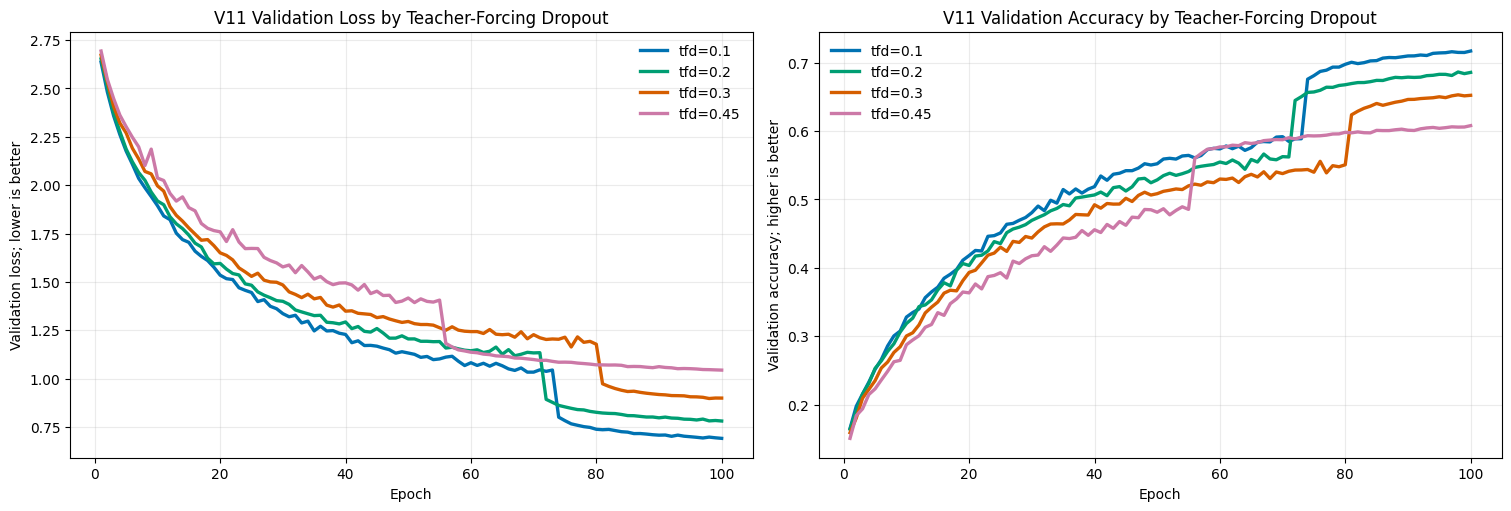

In [131]:
v11_plot_df = v11_summary.copy()
v11_plot_df["plot_label"] = v11_plot_df["teacher_forcing_dropout"].map(lambda x: f"tfd={x:g}")
v11_label_map = dict(zip(v11_plot_df["run_label"], v11_plot_df["plot_label"]))
v11_colors = {0.1: "#0072B2", 0.2: "#009E73", 0.3: "#D55E00", 0.45: "#CC79A7"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for run_label, data in v11_epoch_df.groupby("run_label"):
    meta = v11_plot_df.loc[v11_plot_df["run_label"].eq(run_label)].iloc[0]
    tfd = meta["teacher_forcing_dropout"]
    label = v11_label_map[run_label]
    color = v11_colors.get(tfd, "#666666")
    axes[0].plot(data["epoch"], data["val_loss"], label=label, color=color, linewidth=2.4)
    axes[1].plot(data["epoch"], data["val_accuracy"], label=label, color=color, linewidth=2.4)

axes[0].set_title("V11 Validation Loss by Teacher-Forcing Dropout")
axes[0].set_ylabel("Validation loss; lower is better")
axes[1].set_title("V11 Validation Accuracy by Teacher-Forcing Dropout")
axes[1].set_ylabel("Validation accuracy; higher is better")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()



#### V11 Test Metrics

Teacher-forced metrics and autoregressive metrics answer different questions. Teacher-forced metrics track the training objective, while autoregressive metrics show how well the decoder behaves when it must consume its own previous predictions.


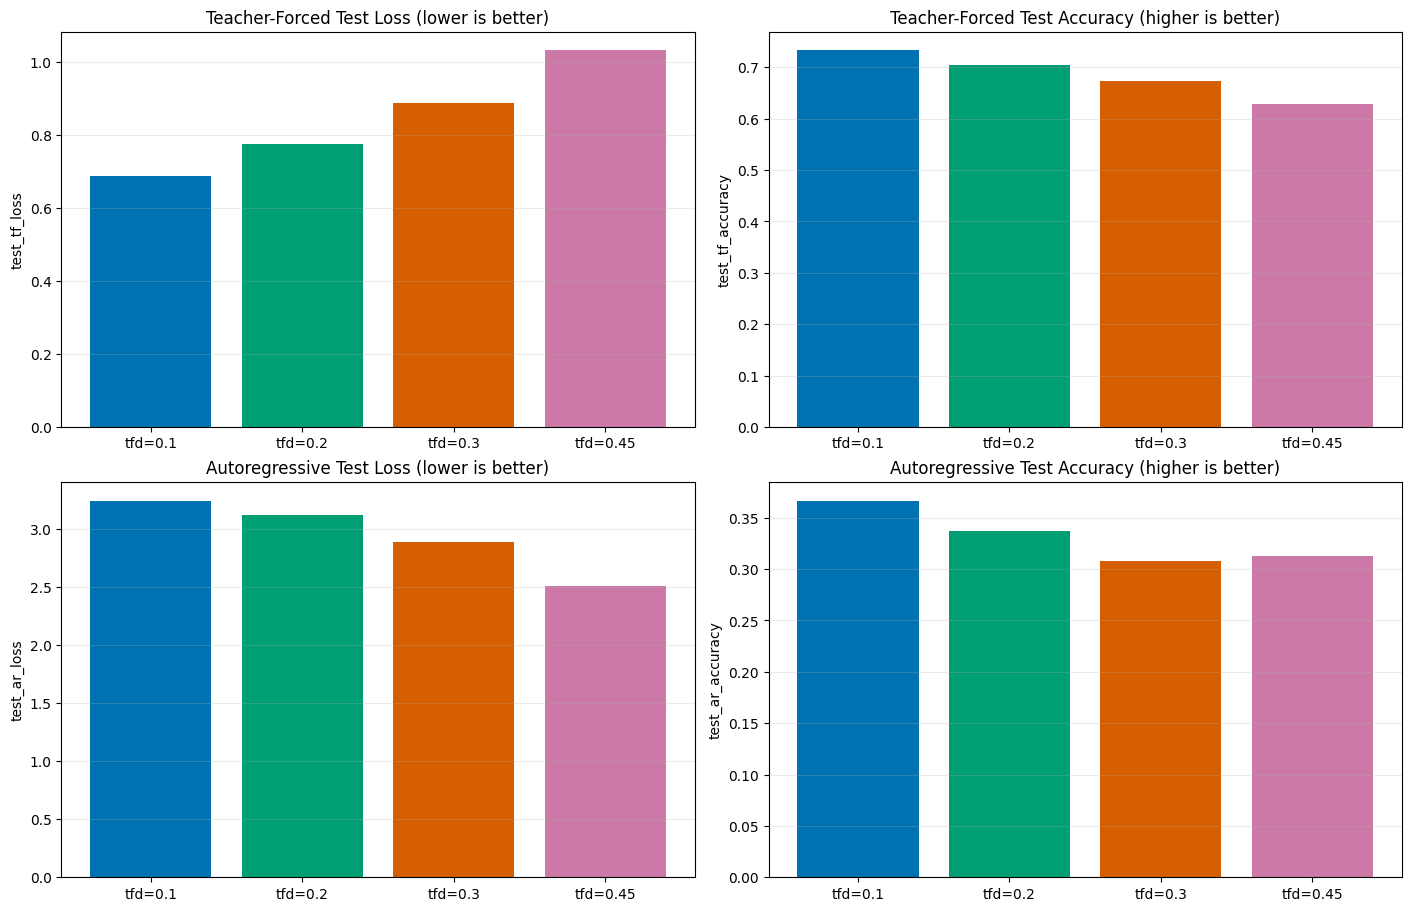

In [132]:
bar_df = v11_summary.copy()
bar_df["plot_label"] = bar_df["teacher_forcing_dropout"].map(lambda x: f"tfd={x:g}")
bar_colors = [v11_colors.get(tfd, "#666666") for tfd in bar_df["teacher_forcing_dropout"]]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
metrics = [
    ("test_tf_loss", "Teacher-Forced Test Loss", "lower is better"),
    ("test_tf_accuracy", "Teacher-Forced Test Accuracy", "higher is better"),
    ("test_ar_loss", "Autoregressive Test Loss", "lower is better"),
    ("test_ar_accuracy", "Autoregressive Test Accuracy", "higher is better"),
]

for ax, (metric, title, direction) in zip(axes.ravel(), metrics):
    ax.bar(bar_df["plot_label"], bar_df[metric], color=bar_colors)
    ax.set_title(f"{title} ({direction})")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.25)
plt.show()



#### Autoregressive Validation Checks

The periodic autoregressive validation snapshots show a tradeoff that is not visible from the teacher-forced curves alone. Lower dropout gets more exact tokens right by the end, while higher dropout produces lower autoregressive loss.


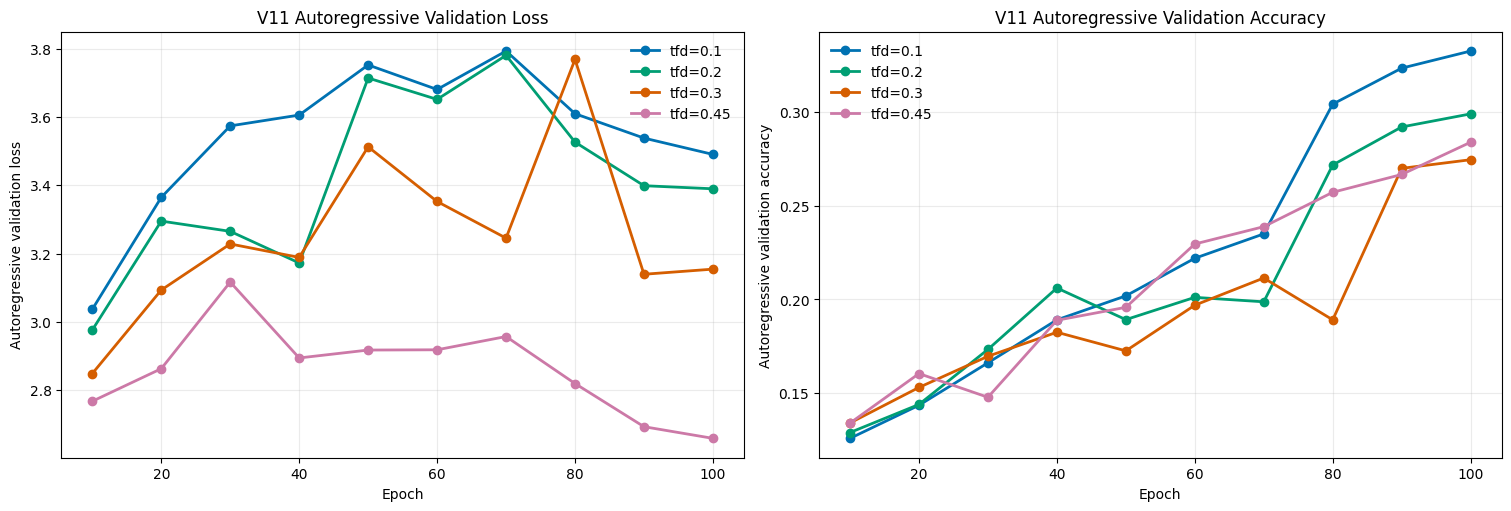

In [133]:
if v11_ar_val_df.empty:
    print("No autoregressive validation snapshots found for v11.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    for run_label, data in v11_ar_val_df.groupby("run_label"):
        meta = v11_plot_df.loc[v11_plot_df["run_label"].eq(run_label)].iloc[0]
        tfd = meta["teacher_forcing_dropout"]
        label = v11_label_map[run_label]
        color = v11_colors.get(tfd, "#666666")
        axes[0].plot(data["epoch"], data["loss"], marker="o", label=label, color=color, linewidth=2)
        axes[1].plot(data["epoch"], data["accuracy"], marker="o", label=label, color=color, linewidth=2)

    axes[0].set_title("V11 Autoregressive Validation Loss")
    axes[0].set_ylabel("Autoregressive validation loss")
    axes[1].set_title("V11 Autoregressive Validation Accuracy")
    axes[1].set_ylabel("Autoregressive validation accuracy")
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)
        ax.legend(frameon=False)
    plt.show()



#### V11 Analysis Takeaway

The v11 sweep is a controlled teacher-forcing dropout comparison. `tfd=0.1` is the strongest overall checkpoint for reconstruction: it has the best validation loss, best validation accuracy, best teacher-forced test loss, best teacher-forced test accuracy, and best autoregressive test accuracy.

The main exception is autoregressive loss. `tfd=0.45` has the lowest autoregressive test loss even though its autoregressive exact-token accuracy is lower than `tfd=0.1`. That suggests heavier teacher-forcing dropout may reduce the severity or confidence of free-running mistakes, but it does not produce the most correct residues overall.

The middle settings do not add much. `tfd=0.2` is consistently second-best on teacher-forced reconstruction and autoregressive accuracy, while `tfd=0.3` is weaker than both `0.1` and `0.2` on the final test metrics. Based on these runs, `tfd=0.1` should be the default v11 candidate for downstream latent-space or reconstruction experiments, with `tfd=0.45` kept only as a stress-test comparison for free-running decoder behavior.


#### V11 Checkpoint-Level Diagnostics Without Retraining

The history files show that `tfd=0.45` has lower autoregressive loss but worse autoregressive top-1 accuracy. To investigate that without retraining, this section reloads the saved v11 checkpoints and computes richer autoregressive diagnostics on a fixed subset of the filtered test split.

By default this uses the first 512 examples from the `length_2_of_3` solubility test loader to keep notebook execution reasonable. Set `V11_DETAILED_MAX_EXAMPLES = None` to evaluate the full filtered test split.


In [134]:
# Checkpoint inference configuration. Set V11_DETAILED_MAX_EXAMPLES = None for the full filtered test split.
V11_DETAILED_MAX_EXAMPLES = 512
V11_DETAILED_BATCH_SIZE = 32
V11_DETAILED_TOP_K = (1, 3, 5)

import sys

SRC_DIR = PROJECT_ROOT / "Code" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from models.autoencoder import ProteinSequenceAutoencoder as AE
from utils.dataloader import (
    BOS_IDX,
    EOS_IDX,
    PAD_IDX,
    VOCAB,
    compute_train_length_boundaries,
    create_dataloader,
)
from utils.hyperparameters import AutoencoderHyperparameters as AEParams

V11_DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
IDX_TO_TOKEN = {idx: token for token, idx in VOCAB.items()}
print(f"Using device for v11 checkpoint diagnostics: {V11_DEVICE}")



Using device for v11 checkpoint diagnostics: mps


##### Diagnostic Helpers

These helpers mirror the project evaluator, but keep everything in memory and add top-k token accuracy, edit distance, length/EOS behavior, first-error position, and confidence summaries.


In [135]:
def notebook_checkpoint_state_dict(checkpoint):
    if not isinstance(checkpoint, dict):
        raise TypeError("Checkpoint must be a state_dict or contain 'model_state_dict'.")
    if "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]
    return checkpoint


def notebook_rnn_num_layers(state_dict, prefix):
    layer_ids = set()
    for key in state_dict:
        if not key.startswith(f"{prefix}.weight_ih_l"):
            continue
        layer_name = key.removeprefix(f"{prefix}.weight_ih_l").removesuffix("_reverse")
        if layer_name.isdigit():
            layer_ids.add(int(layer_name))
    return max(layer_ids) + 1 if layer_ids else 1


def notebook_ae_params_from_state_dict(hyperparams, state_dict):
    params = hyperparams.__dict__.copy()
    params.update(
        {
            "embedding_dim": state_dict["embedding.weight"].shape[1],
            "cnn_out_channels": state_dict["cnn.weight"].shape[0],
            "hidden_dim": state_dict["encoder.weight_hh_l0"].shape[1],
            "latent_dim": state_dict["to_latent.weight"].shape[0],
            "num_layers": notebook_rnn_num_layers(state_dict, "encoder"),
            "kernel_size": state_dict["cnn.weight"].shape[2],
            "bidirectional": "encoder.weight_ih_l0_reverse" in state_dict,
            "condition_decoder_on_latent": (
                state_dict["decoder.weight_ih_l0"].shape[1]
                == state_dict["embedding.weight"].shape[1] + state_dict["to_latent.weight"].shape[0]
            ),
            "pad_idx": PAD_IDX,
            "bos_idx": BOS_IDX,
            "eos_idx": EOS_IDX,
        }
    )
    for training_only_param in (
        "learning_rate",
        "batch_size",
        "num_epochs",
        "shuffle",
        "patience",
        "lr_patience",
        "scheduler_factor",
    ):
        params.pop(training_only_param, None)
    return params


def load_notebook_ae(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=V11_DEVICE)
    state_dict = notebook_checkpoint_state_dict(checkpoint)
    model = AE(**notebook_ae_params_from_state_dict(AEParams(), state_dict)).to(V11_DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def token_ids_to_sequence(token_ids):
    decoded = []
    for token_id in token_ids.tolist():
        if token_id in {PAD_IDX, BOS_IDX}:
            continue
        if token_id == EOS_IDX:
            break
        decoded.append(IDX_TO_TOKEN.get(int(token_id), "<UNK>"))
    return "".join(decoded)


def levenshtein_distance(a, b):
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, char_a in enumerate(a, start=1):
        current = [i]
        for j, char_b in enumerate(b, start=1):
            current.append(
                min(
                    previous[j] + 1,
                    current[j - 1] + 1,
                    previous[j - 1] + (char_a != char_b),
                )
            )
        previous = current
    return previous[-1]


def first_error_position(target_ids, predicted_ids):
    non_pad_positions = (target_ids != PAD_IDX).nonzero(as_tuple=True)[0]
    for pos in non_pad_positions.tolist():
        if int(target_ids[pos]) != int(predicted_ids[pos]):
            return pos + 1
    return math.nan


def eos_position(token_ids):
    eos_positions = (token_ids == EOS_IDX).nonzero(as_tuple=True)[0]
    return int(eos_positions[0].item() + 1) if len(eos_positions) else math.nan




##### Build the Fixed Test Loader

This uses the same `thirds`, bin `2` length filtering implied by the v11 checkpoint names.


In [136]:
V11_DATA_DIR = PROJECT_ROOT / "data" / "processed" / "peer"
print(f"Using v11 diagnostic data directory: {V11_DATA_DIR}")
if not (V11_DATA_DIR / "solubility" / "train.csv").exists():
    raise FileNotFoundError(
        f"Expected solubility train CSV at {V11_DATA_DIR / 'solubility' / 'train.csv'}. "
        "Reload the notebook from disk if this cell still calls create_dataloader without data_dir=."
    )

v11_train_loader_for_boundaries = create_dataloader(
    task="solubility",
    split="train",
    data_dir=V11_DATA_DIR,
    mode="autoencoder",
    encoding="char",
    batch_size=V11_DETAILED_BATCH_SIZE,
    shuffle=False,
)
v11_length_boundaries = compute_train_length_boundaries(v11_train_loader_for_boundaries.dataset, num_bins=3)
v11_test_loader_full = create_dataloader(
    task="solubility",
    split="test",
    data_dir=V11_DATA_DIR,
    mode="autoencoder",
    encoding="char",
    batch_size=V11_DETAILED_BATCH_SIZE,
    shuffle=False,
    loader_type="length_bin",
    length_options="thirds",
    length_bin=2,
    length_boundaries=v11_length_boundaries,
)

if V11_DETAILED_MAX_EXAMPLES is None:
    v11_test_dataset = v11_test_loader_full.dataset
else:
    n_examples = min(V11_DETAILED_MAX_EXAMPLES, len(v11_test_loader_full.dataset))
    v11_test_dataset = Subset(v11_test_loader_full.dataset, list(range(n_examples)))

v11_diagnostic_loader = DataLoader(
    v11_test_dataset,
    batch_size=V11_DETAILED_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=v11_test_loader_full.collate_fn,
)

print(f"Full v11 length-bin test examples: {len(v11_test_loader_full.dataset)}")
print(f"Diagnostic examples evaluated per checkpoint: {len(v11_test_dataset)}")





Using v11 diagnostic data directory: /Users/josh/GWU/protein-sequence-augmentation/data/processed/peer
[cache] Loaded 62478 examples from cache: solubility_train_autoencoder_char_sequence_label_True_8957e810.pkl
[cache] Loaded 1999 examples from cache: solubility_test_autoencoder_char_sequence_label_True_91ffec24.pkl
Full v11 length-bin test examples: 565
Diagnostic examples evaluated per checkpoint: 512


##### Run Checkpoint Diagnostics

This cell performs inference with the four saved v11 checkpoints. It does not train and does not write outputs.


In [137]:
def evaluate_v11_checkpoint_diagnostics(model, dataloader, run_label, tfd):
    loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction="sum")
    totals = {
        "tokens": 0,
        "loss_sum": 0.0,
        "correct_top1": 0,
        "correct_top3": 0,
        "correct_top5": 0,
        "correct_prob_sum": 0.0,
        "target_rank_sum": 0.0,
        "entropy_sum": 0.0,
        "examples": 0,
        "sequence_exact_matches": 0,
        "edit_distance_sum": 0.0,
        "normalized_edit_distance_sum": 0.0,
        "length_error_sum": 0.0,
        "abs_length_error_sum": 0.0,
        "premature_eos": 0,
        "late_or_missing_eos": 0,
        "first_error_sum": 0.0,
        "first_error_count": 0,
    }
    example_rows = []

    with torch.no_grad():
        for batch in dataloader:
            inputs = batch["input_ids"].to(V11_DEVICE)
            lengths = batch["length"].to(V11_DEVICE)
            targets = batch["target_ids"].to(V11_DEVICE)[:, 1:]
            latent = model.encode(inputs, lengths=lengths)
            logits = model.decode_autoregressive(latent, max_length=targets.size(1))
            probs = torch.softmax(logits, dim=-1)
            predictions = logits.argmax(dim=-1)
            non_pad = targets != PAD_IDX
            batch_tokens = int(non_pad.sum().item())

            totals["loss_sum"] += float(loss_fn(logits.reshape(-1, logits.size(-1)), targets.reshape(-1)).item())
            totals["tokens"] += batch_tokens
            top_values, top_indices = logits.topk(max(V11_DETAILED_TOP_K), dim=-1)
            expanded_targets = targets.unsqueeze(-1)
            top_matches = top_indices.eq(expanded_targets) & non_pad.unsqueeze(-1)
            totals["correct_top1"] += int((predictions[non_pad] == targets[non_pad]).sum().item())
            totals["correct_top3"] += int(top_matches[:, :, :3].any(dim=-1).sum().item())
            totals["correct_top5"] += int(top_matches[:, :, :5].any(dim=-1).sum().item())

            correct_probs = probs.gather(-1, expanded_targets.clamp_min(0)).squeeze(-1)
            entropy = -(probs.clamp_min(1e-12) * probs.clamp_min(1e-12).log()).sum(dim=-1)
            totals["correct_prob_sum"] += float(correct_probs[non_pad].sum().item())
            totals["entropy_sum"] += float(entropy[non_pad].sum().item())

            sorted_indices = logits.argsort(dim=-1, descending=True)
            target_ranks = sorted_indices.eq(expanded_targets).float().argmax(dim=-1) + 1
            totals["target_rank_sum"] += float(target_ranks[non_pad].sum().item())

            for row_idx in range(targets.size(0)):
                target_ids = targets[row_idx].detach().cpu()
                predicted_ids = predictions[row_idx].detach().cpu()
                target_seq = token_ids_to_sequence(target_ids)
                predicted_seq = token_ids_to_sequence(predicted_ids)
                edit_distance = levenshtein_distance(target_seq, predicted_seq)
                normalized_edit_distance = edit_distance / max(len(target_seq), 1)
                length_error = len(predicted_seq) - len(target_seq)
                exact_match = target_seq == predicted_seq
                first_error = first_error_position(target_ids, predicted_ids)
                target_eos = eos_position(target_ids)
                predicted_eos = eos_position(predicted_ids)

                totals["examples"] += 1
                totals["sequence_exact_matches"] += int(exact_match)
                totals["edit_distance_sum"] += edit_distance
                totals["normalized_edit_distance_sum"] += normalized_edit_distance
                totals["length_error_sum"] += length_error
                totals["abs_length_error_sum"] += abs(length_error)
                if pd.notna(first_error):
                    totals["first_error_sum"] += first_error
                    totals["first_error_count"] += 1
                if pd.notna(predicted_eos) and pd.notna(target_eos) and predicted_eos < target_eos:
                    totals["premature_eos"] += 1
                if pd.isna(predicted_eos) or (pd.notna(target_eos) and predicted_eos > target_eos):
                    totals["late_or_missing_eos"] += 1

                if len(example_rows) < 24:
                    example_rows.append(
                        {
                            "run_label": run_label,
                            "teacher_forcing_dropout": tfd,
                            "example_index": totals["examples"] - 1,
                            "target_length": len(target_seq),
                            "predicted_length": len(predicted_seq),
                            "length_error": length_error,
                            "edit_distance": edit_distance,
                            "normalized_edit_distance": normalized_edit_distance,
                            "first_error_position": first_error,
                            "target_sequence": target_seq,
                            "predicted_sequence": predicted_seq,
                        }
                    )

    tokens = totals["tokens"]
    examples = totals["examples"]
    return (
        {
            "run_label": run_label,
            "teacher_forcing_dropout": tfd,
            "examples": examples,
            "tokens": tokens,
            "ar_loss": totals["loss_sum"] / tokens if tokens else math.nan,
            "top1_accuracy": totals["correct_top1"] / tokens if tokens else math.nan,
            "top3_accuracy": totals["correct_top3"] / tokens if tokens else math.nan,
            "top5_accuracy": totals["correct_top5"] / tokens if tokens else math.nan,
            "mean_correct_token_probability": totals["correct_prob_sum"] / tokens if tokens else math.nan,
            "mean_target_rank": totals["target_rank_sum"] / tokens if tokens else math.nan,
            "mean_token_entropy": totals["entropy_sum"] / tokens if tokens else math.nan,
            "sequence_exact_match_rate": totals["sequence_exact_matches"] / examples if examples else math.nan,
            "mean_edit_distance": totals["edit_distance_sum"] / examples if examples else math.nan,
            "mean_normalized_edit_distance": totals["normalized_edit_distance_sum"] / examples if examples else math.nan,
            "mean_length_error": totals["length_error_sum"] / examples if examples else math.nan,
            "mean_abs_length_error": totals["abs_length_error_sum"] / examples if examples else math.nan,
            "premature_eos_rate": totals["premature_eos"] / examples if examples else math.nan,
            "late_or_missing_eos_rate": totals["late_or_missing_eos"] / examples if examples else math.nan,
            "mean_first_error_position": totals["first_error_sum"] / totals["first_error_count"] if totals["first_error_count"] else math.nan,
        },
        example_rows,
    )


v11_diagnostic_summaries = []
v11_diagnostic_examples = []
for _, run in v11_summary.sort_values("teacher_forcing_dropout").iterrows():
    print(f"Evaluating {run['plot_label'] if 'plot_label' in run else run['run_label']} ...")
    model = load_notebook_ae(PROJECT_ROOT / run["checkpoint"])
    summary, examples = evaluate_v11_checkpoint_diagnostics(
        model,
        v11_diagnostic_loader,
        run["run_label"],
        run["teacher_forcing_dropout"],
    )
    v11_diagnostic_summaries.append(summary)
    v11_diagnostic_examples.extend(examples)
    del model
    if V11_DEVICE.type == "cuda":
        torch.cuda.empty_cache()

v11_diagnostic_summary = pd.DataFrame(v11_diagnostic_summaries).sort_values("teacher_forcing_dropout").reset_index(drop=True)
v11_diagnostic_examples = pd.DataFrame(v11_diagnostic_examples)
v11_diagnostic_summary



Evaluating latent256_tfd0p1_lr0p0003_lrp3_sf0p1 ...
Evaluating latent256_tfd0p2_lr0p0003_lrp3_sf0p1 ...
Evaluating latent256_tfd0p3_lr0p0003_lrp3_sf0p1 ...
Evaluating latent256_tfd0p45_lr0p0003_lrp3_sf0p1 ...


,run_label,teacher_forcing_dropout,examples,tokens,ar_loss,top1_accuracy,top3_accuracy,top5_accuracy,mean_correct_token_probability,mean_target_rank,mean_token_entropy,sequence_exact_match_rate,mean_edit_distance,mean_normalized_edit_distance,mean_length_error,mean_abs_length_error,premature_eos_rate,late_or_missing_eos_rate,mean_first_error_position
0,latent256_tfd0p1_lr0p0003_lrp3_sf0p1,0.10,512,141134,3.845018,0.226451,0.486686,0.669931,0.211308,4.708298,1.090722,0.0,163.986328,0.592265,-1.832031,2.070312,0.748047,0.093750,10.007812
1,latent256_tfd0p2_lr0p0003_lrp3_sf0p1,0.20,512,141134,3.572798,0.213032,0.456134,0.645507,0.200181,4.821049,1.237750,0.0,165.130859,0.596239,-3.615234,3.677734,0.951172,0.017578,12.423828
2,latent256_tfd0p3_lr0p0003_lrp3_sf0p1,0.30,512,141134,3.215315,0.203735,0.448312,0.647937,0.194975,4.808792,1.385906,0.0,164.882812,0.595870,-4.566406,4.574219,0.992188,0.003906,12.783203
3,latent256_tfd0p45_lr0p0003_lrp3_sf0p1,0.45,512,141134,2.866361,0.213223,0.455248,0.653443,0.198013,4.773697,1.577704,0.0,162.445312,0.586762,-3.839844,3.847656,0.994141,0.001953,12.250000


##### Interpret the Diagnostics

These plots separate “near misses” from exact-token accuracy and show whether the lower autoregressive loss at high dropout is associated with better ranking/calibration, sequence edit distance, or length/EOS behavior.


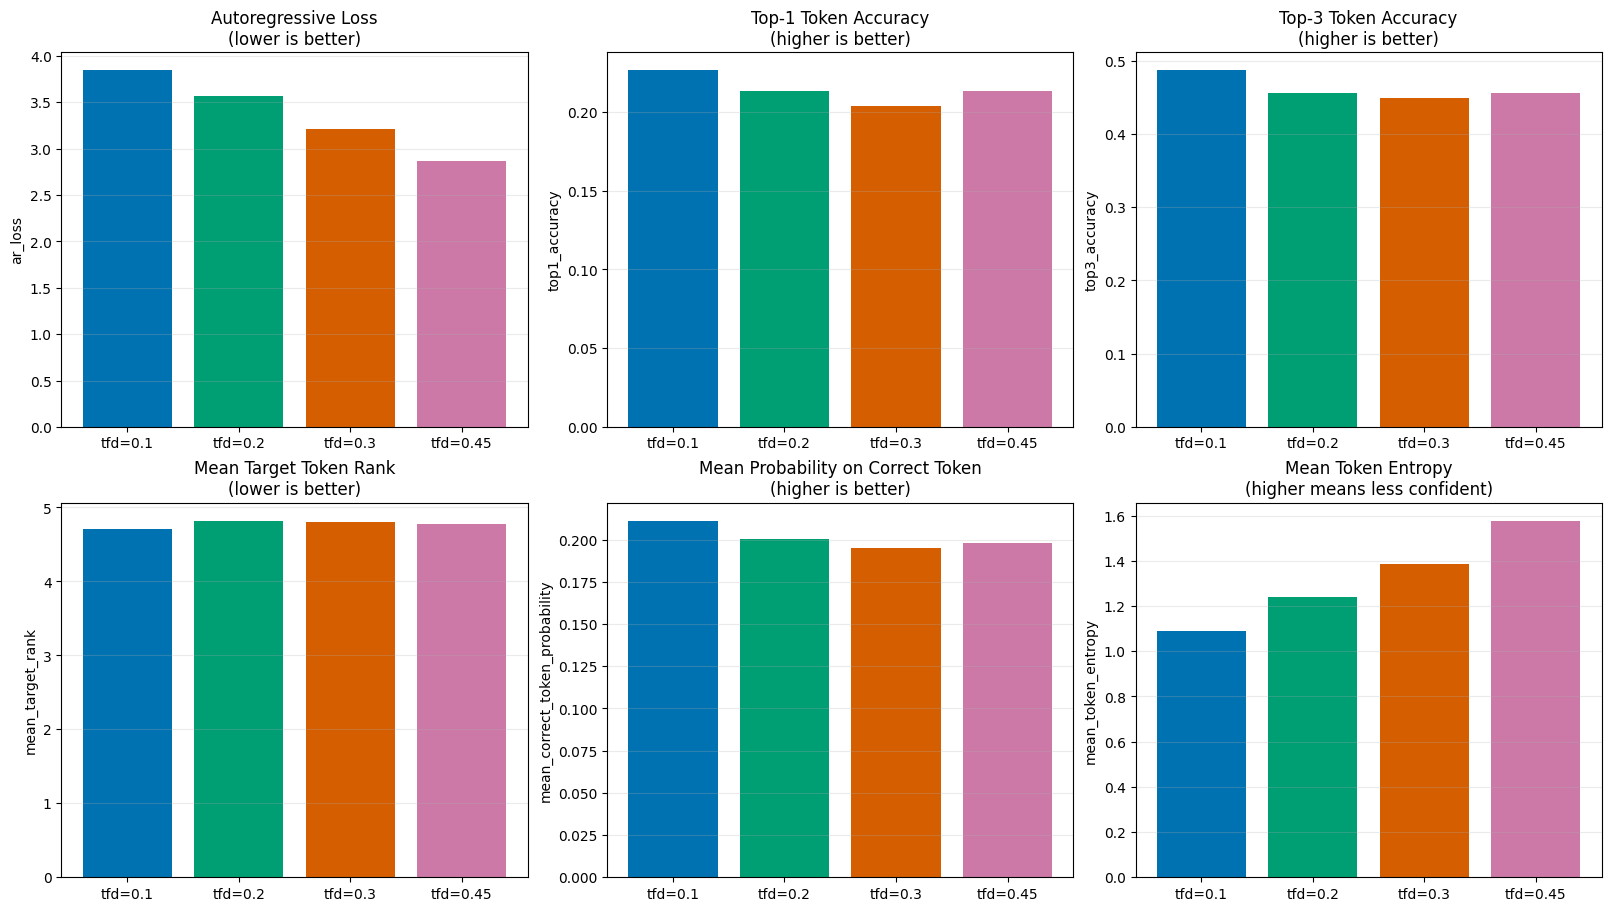

In [138]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
plot_metrics = [
    ("ar_loss", "Autoregressive Loss", "lower is better"),
    ("top1_accuracy", "Top-1 Token Accuracy", "higher is better"),
    ("top3_accuracy", "Top-3 Token Accuracy", "higher is better"),
    ("mean_target_rank", "Mean Target Token Rank", "lower is better"),
    ("mean_correct_token_probability", "Mean Probability on Correct Token", "higher is better"),
    ("mean_token_entropy", "Mean Token Entropy", "higher means less confident"),
]
bar_df = v11_diagnostic_summary.copy()
bar_df["plot_label"] = bar_df["teacher_forcing_dropout"].map(lambda x: f"tfd={x:g}")
colors = [v11_colors.get(tfd, "#666666") for tfd in bar_df["teacher_forcing_dropout"]]

for ax, (metric, title, subtitle) in zip(axes.ravel(), plot_metrics):
    ax.bar(bar_df["plot_label"], bar_df[metric], color=colors)
    ax.set_title(f"{title}\n({subtitle})")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.25)
plt.show()




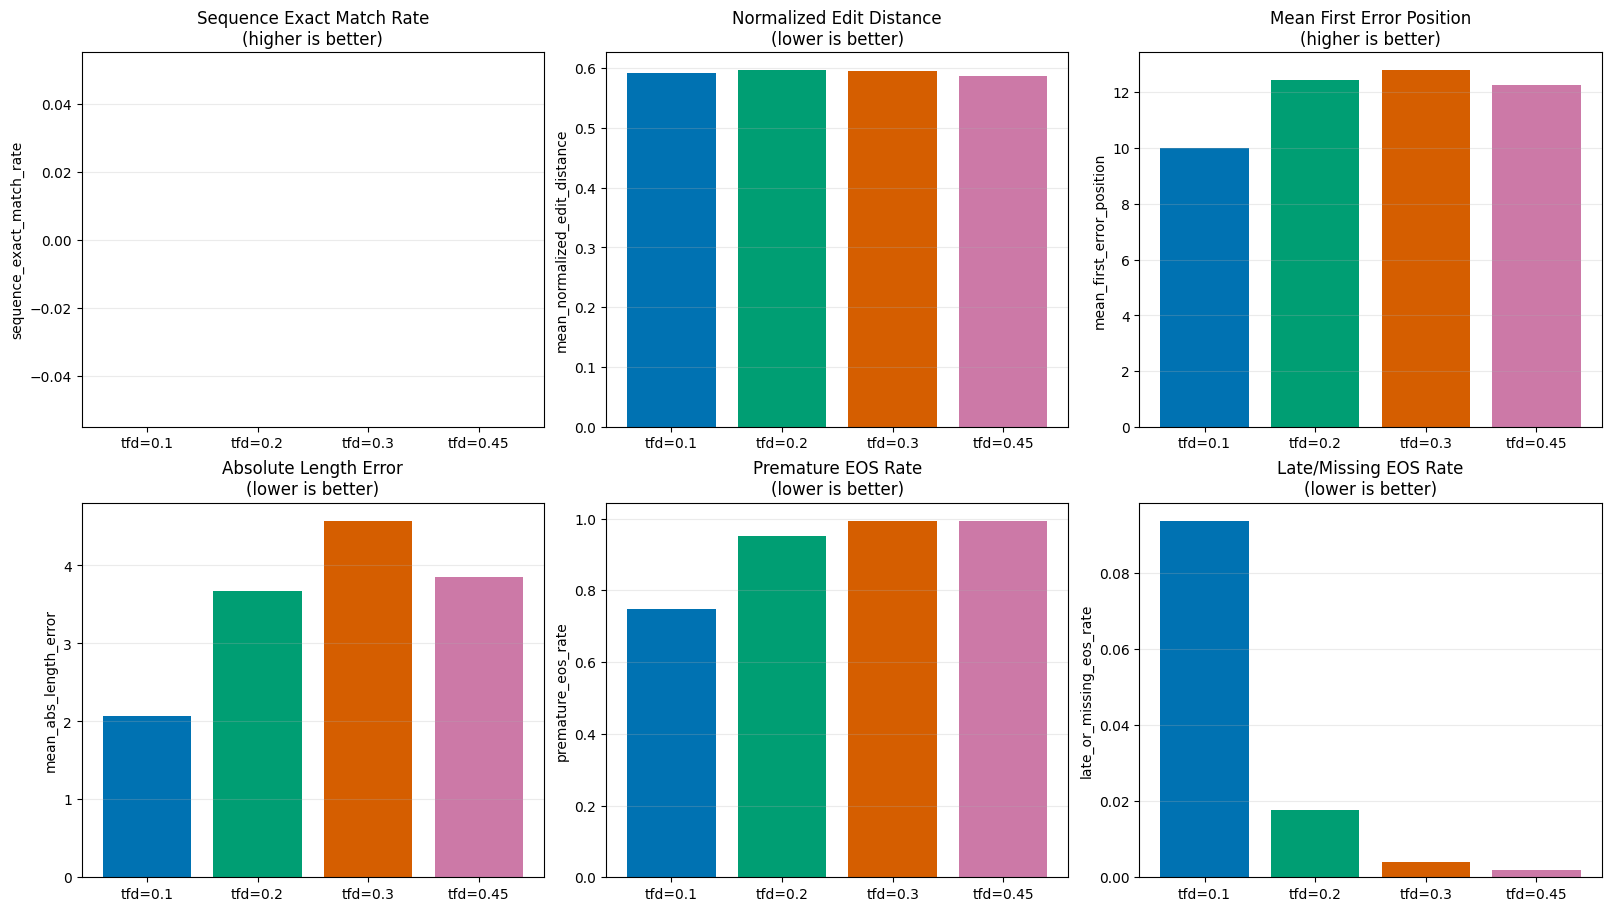

In [139]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
sequence_metrics = [
    ("sequence_exact_match_rate", "Sequence Exact Match Rate", "higher is better"),
    ("mean_normalized_edit_distance", "Normalized Edit Distance", "lower is better"),
    ("mean_first_error_position", "Mean First Error Position", "higher is better"),
    ("mean_abs_length_error", "Absolute Length Error", "lower is better"),
    ("premature_eos_rate", "Premature EOS Rate", "lower is better"),
    ("late_or_missing_eos_rate", "Late/Missing EOS Rate", "lower is better"),
]

for ax, (metric, title, subtitle) in zip(axes.ravel(), sequence_metrics):
    ax.bar(bar_df["plot_label"], bar_df[metric], color=colors)
    ax.set_title(f"{title}\n({subtitle})")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.25)
plt.show()




##### Example Reconstructions

These examples are not a substitute for aggregate metrics, but they make the failure modes easier to inspect: early divergence, length drift, repeated motifs, and near-correct reconstructions.


In [140]:
example_display_cols = [
    "teacher_forcing_dropout",
    "example_index",
    "target_length",
    "predicted_length",
    "length_error",
    "edit_distance",
    "normalized_edit_distance",
    "first_error_position",
    "target_sequence",
    "predicted_sequence",
]

v11_diagnostic_examples[example_display_cols].head(24)



,teacher_forcing_dropout,example_index,target_length,predicted_length,length_error,edit_distance,normalized_edit_distance,first_error_position,target_sequence,predicted_sequence
0,0.1,0,222,221,-1,130,0.585586,7,MANMLVASSSKTLPTTTTTTITPKPKFPLLKTPLLKLSPPQLPPLK...,MANMLVSASSTKKPTLPTTITTTTKFPLKPLKPLPLPSLQKLPLPH...
1,0.1,1,322,317,-5,208,0.645963,8,MAVVSTSLASQITNPNSAVSTQFSGLRRSFLKLENSVSTQSSFFQN...,MAVVSTSSALQINQPTSASVTFLNGRSFSLKENQTVSSFSRLSQLS...
2,0.1,2,230,231,1,136,0.591304,6,MASFTLSSATPSQLCSSKNGMFAPSLALAKAGRVNVLISKERIRGM...,MASFTSLTSSAPQLCSAFKNGMPSLASALKNGRVVAILKRESFGIM...
3,0.1,3,267,266,-1,166,0.621723,10,MSLKHFTAIDTHTIHETTIIEKEYVDTHHVENFVENFAKVYYSWEQ...,MSLKHFTAITDITDIETTHIEHTHYVKEVEEFNVNVAFYKDISWQS...
4,0.1,4,233,233,0,115,0.493562,9,MSEHSIRGSIVYEGLTWITAMGYNVTDFLVNMLEQMKCPENWSGLH...,MSEHSIRGISVYGYETWLIAMTGNVTDFLVNMWQELKCEMPNSGPH...
5,0.1,5,220,220,0,116,0.527273,9,MTQMRFTEEDFNTFTIEGLDARMEVLKETVRPKLTALGEHFAPTLS...,MTQMRFTETFDNETMDIEGLARELVTKFREVPKTLALAGHPTELSM...
6,0.1,6,311,311,0,200,0.643087,3,MKPTLFLLAAGMGSRYGGLKQLDGLGPNGETIMDYSIYDAINAGFG...,MKLTPFALLGLMGSRYGPAKQDGLGLMNEGTIYSDGIIYNDLAFGK...
7,0.1,7,229,230,1,112,0.489083,5,MNIRMGTKGKRPLRSLTPRDKIHAIQRIHDGESKASVARDIGVPES...,MNIRGMTKRKLPGTSPRRKDILHAIQRIDEHGSKASVRDIAVPGTE...
8,0.1,8,295,293,-2,190,0.644068,3,MKSFFSIFGDPSVTSVAIGKFDGMHLAHQRLFSYLDEGGAILTVDA...,MKFSSSIGDPVFITAFVSKGFLSMHHDGQRALYDIAEGLLFTGVDA...
9,0.1,9,235,237,2,116,0.493617,9,MSLNHTDLLFAKETKHEPLLLSHRGAHPDYVLTSDEINGCSEIQLA...,MSLNHTDLTFAKELLHLPKHESLRPGADYHVTLSDEINGCSLEQIT...


##### How to Read This Section

If `tfd=0.45` has better top-3/top-5 accuracy, lower mean target rank, or lower normalized edit distance despite worse top-1 accuracy, then the low autoregressive loss probably reflects useful near-miss behavior. That would make a teacher-forcing dropout curriculum more compelling.

If `tfd=0.45` only has higher entropy or lower confidence while edit distance, first-error position, and length/EOS behavior remain worse, then the lower loss is probably not enough evidence for a curriculum. In that case, the next higher-ROI change would be elsewhere: decoding constraints, length/EOS handling, latent size, or a different objective/evaluation target.


#### V11 EOS, Length, and Per-Position Diagnostics

The previous diagnostic pass suggests `tfd=0.1` is the best default, but all v11 models have weak autoregressive sequence recovery and high premature-EOS rates. This section keeps the same no-retraining setup and adds targeted diagnostics for EOS timing, length drift, and position-wise accuracy.

The goal is to separate three possible failure modes:

- The decoder predicts EOS too early.
- Accuracy collapses after a particular position even when length is reasonable.
- The model is mostly reconstructing local composition but not preserving long-range token order.


In [141]:
# pyright: reportUnreachable=false
# Bootstrap prerequisites for running the EOS/position section independently.
# This cell is intentionally defensive so the section can run after a kernel restart.
from pathlib import Path
import json
import math
import re
import sys

import pandas as pd
import matplotlib.pyplot as plt

if "PROJECT_ROOT" not in globals():
    NOTEBOOK_DIR = Path.cwd()
    PROJECT_ROOT = NOTEBOOK_DIR
    for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
        if (candidate / "Code" / "results" / "tables" / "autoencoder_results.csv").exists():
            PROJECT_ROOT = candidate
            break

if "RESULTS_ROOT" not in globals():
    RESULTS_ROOT = PROJECT_ROOT / "Code" / "results" / "autoencoder" / "solubility"
if "CHECKPOINT_ROOT" not in globals():
    CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints" / "autoencoder" / "solubility"

SRC_DIR = PROJECT_ROOT / "Code" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from models.autoencoder import ProteinSequenceAutoencoder as AE
from utils.dataloader import (
    BOS_IDX,
    EOS_IDX,
    PAD_IDX,
    VOCAB,
    compute_train_length_boundaries,
    create_dataloader,
)
from utils.hyperparameters import AutoencoderHyperparameters as AEParams

V11_DETAILED_MAX_EXAMPLES = globals().get("V11_DETAILED_MAX_EXAMPLES", 512)
V11_DETAILED_BATCH_SIZE = globals().get("V11_DETAILED_BATCH_SIZE", 32)
V11_DETAILED_TOP_K = globals().get("V11_DETAILED_TOP_K", (1, 3, 5))
V11_DEVICE = globals().get(
    "V11_DEVICE",
    torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"),
)
IDX_TO_TOKEN = {idx: token for token, idx in VOCAB.items()}
v11_colors = globals().get(
    "v11_colors",
    {0.1: "#0072B2", 0.2: "#009E73", 0.3: "#D55E00", 0.45: "#CC79A7"},
)


def _v11_parse_history_metadata(path):
    name = path.name
    version = path.parent.name
    latent_match = re.search(r"latent(\d+)", name)
    tfd_match = re.search(r"tfd(\d+)p(\d+)", name)
    sf_match = re.search(r"sf(\d+)p(\d+)", name)
    return {
        "version": version,
        "run_label": name.removesuffix("_history.json").replace(f"{version}_model_ae_length_2_of_3_solubility_", ""),
        "history_path": str(path.relative_to(PROJECT_ROOT)),
        "latent_dim": int(latent_match.group(1)) if latent_match else None,
        "teacher_forcing_dropout": float(f"{tfd_match.group(1)}.{tfd_match.group(2)}") if tfd_match else None,
        "scheduler_factor_suffix": float(f"{sf_match.group(1)}.{sf_match.group(2)}") if sf_match else None,
    }


def _v11_checkpoint_path_from_history(history_path):
    name = history_path.name
    version = history_path.parent.name
    if name.startswith(f"{version}_"):
        name = name[len(version) + 1:]
    return CHECKPOINT_ROOT / version / (name.removesuffix("_history.json") + ".pt")


def _v11_summarize_history(path):
    with path.open() as f:
        history = json.load(f)
    meta = _v11_parse_history_metadata(path)
    hp = history.get("hyperparameters", {})
    epochs = pd.DataFrame(history.get("epochs", []))
    test = history.get("test", {})
    checkpoint_path = _v11_checkpoint_path_from_history(path)
    best_loss = epochs.loc[epochs["val_loss"].idxmin()]
    best_acc = epochs.loc[epochs["val_accuracy"].idxmax()]
    return {
        **meta,
        "checkpoint": str(checkpoint_path.relative_to(PROJECT_ROOT)),
        "checkpoint_exists": checkpoint_path.exists(),
        "epochs": len(epochs),
        "learning_rate": hp.get("learning_rate"),
        "lr_patience": hp.get("lr_patience"),
        "scheduler_factor": hp.get("scheduler_factor"),
        "best_val_loss": best_loss["val_loss"],
        "best_val_loss_epoch": int(best_loss["epoch"]),
        "best_val_accuracy": best_acc["val_accuracy"],
        "best_val_accuracy_epoch": int(best_acc["epoch"]),
        "test_tf_loss": test.get("teacher_forced", {}).get("loss"),
        "test_tf_accuracy": test.get("teacher_forced", {}).get("accuracy"),
        "test_ar_loss": test.get("autoregressive", {}).get("loss"),
        "test_ar_accuracy": test.get("autoregressive", {}).get("accuracy"),
    }


if "v11_summary" not in globals():
    v11_paths = sorted((RESULTS_ROOT / "v11").glob("v11_*_history.json"))
    v11_summary = pd.DataFrame([_v11_summarize_history(path) for path in v11_paths]).sort_values(
        "teacher_forcing_dropout"
    ).reset_index(drop=True)


def notebook_checkpoint_state_dict(checkpoint):
    if not isinstance(checkpoint, dict):
        raise TypeError("Checkpoint must be a state_dict or contain 'model_state_dict'.")
    if "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]
    return checkpoint


def notebook_rnn_num_layers(state_dict, prefix):
    layer_ids = set()
    for key in state_dict:
        if not key.startswith(f"{prefix}.weight_ih_l"):
            continue
        layer_name = key.removeprefix(f"{prefix}.weight_ih_l").removesuffix("_reverse")
        if layer_name.isdigit():
            layer_ids.add(int(layer_name))
    return max(layer_ids) + 1 if layer_ids else 1


def notebook_ae_params_from_state_dict(hyperparams, state_dict):
    params = hyperparams.__dict__.copy()
    params.update(
        {
            "embedding_dim": state_dict["embedding.weight"].shape[1],
            "cnn_out_channels": state_dict["cnn.weight"].shape[0],
            "hidden_dim": state_dict["encoder.weight_hh_l0"].shape[1],
            "latent_dim": state_dict["to_latent.weight"].shape[0],
            "num_layers": notebook_rnn_num_layers(state_dict, "encoder"),
            "kernel_size": state_dict["cnn.weight"].shape[2],
            "bidirectional": "encoder.weight_ih_l0_reverse" in state_dict,
            "condition_decoder_on_latent": (
                state_dict["decoder.weight_ih_l0"].shape[1]
                == state_dict["embedding.weight"].shape[1] + state_dict["to_latent.weight"].shape[0]
            ),
            "pad_idx": PAD_IDX,
            "bos_idx": BOS_IDX,
            "eos_idx": EOS_IDX,
        }
    )
    for training_only_param in (
        "learning_rate",
        "batch_size",
        "num_epochs",
        "shuffle",
        "patience",
        "lr_patience",
        "scheduler_factor",
    ):
        params.pop(training_only_param, None)
    return params


def load_notebook_ae(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=V11_DEVICE)
    state_dict = notebook_checkpoint_state_dict(checkpoint)
    model = AE(**notebook_ae_params_from_state_dict(AEParams(), state_dict)).to(V11_DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def token_ids_to_sequence(token_ids):
    decoded = []
    for token_id in token_ids.tolist():
        if token_id in {PAD_IDX, BOS_IDX}:
            continue
        if token_id == EOS_IDX:
            break
        decoded.append(IDX_TO_TOKEN.get(int(token_id), "<UNK>"))
    return "".join(decoded)


def eos_position(token_ids):
    eos_positions = (token_ids == EOS_IDX).nonzero(as_tuple=True)[0]
    return int(eos_positions[0].item() + 1) if len(eos_positions) else math.nan


def first_error_position(target_ids, predicted_ids):
    non_pad_positions = (target_ids != PAD_IDX).nonzero(as_tuple=True)[0]
    for pos in non_pad_positions.tolist():
        if int(target_ids[pos]) != int(predicted_ids[pos]):
            return pos + 1
    return math.nan


if "v11_diagnostic_loader" not in globals():
    V11_DATA_DIR = PROJECT_ROOT / "data" / "processed" / "peer"
    print(f"Using v11 diagnostic data directory: {V11_DATA_DIR}")
    if not (V11_DATA_DIR / "solubility" / "train.csv").exists():
        raise FileNotFoundError(f"Expected solubility train CSV at {V11_DATA_DIR / 'solubility' / 'train.csv'}")

    v11_train_loader_for_boundaries = create_dataloader(
        task="solubility",
        split="train",
        data_dir=V11_DATA_DIR,
        mode="autoencoder",
        encoding="char",
        batch_size=V11_DETAILED_BATCH_SIZE,
        shuffle=False,
    )
    v11_length_boundaries = compute_train_length_boundaries(v11_train_loader_for_boundaries.dataset, num_bins=3)
    v11_test_loader_full = create_dataloader(
        task="solubility",
        split="test",
        data_dir=V11_DATA_DIR,
        mode="autoencoder",
        encoding="char",
        batch_size=V11_DETAILED_BATCH_SIZE,
        shuffle=False,
        loader_type="length_bin",
        length_options="thirds",
        length_bin=2,
        length_boundaries=v11_length_boundaries,
    )
    if V11_DETAILED_MAX_EXAMPLES is None:
        v11_test_dataset = v11_test_loader_full.dataset
    else:
        n_examples = min(V11_DETAILED_MAX_EXAMPLES, len(v11_test_loader_full.dataset))
        v11_test_dataset = Subset(v11_test_loader_full.dataset, list(range(n_examples)))

    v11_diagnostic_loader = DataLoader(
        v11_test_dataset,
        batch_size=V11_DETAILED_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=v11_test_loader_full.collate_fn,
    )
    print(f"Full v11 length-bin test examples: {len(v11_test_loader_full.dataset)}")
    print(f"Diagnostic examples evaluated per checkpoint: {len(v11_test_dataset)}")

print(f"Ready: {len(v11_summary)} v11 runs, device={V11_DEVICE}")





Ready: 4 v11 runs, device=mps


In [142]:
def evaluate_v11_position_eos_diagnostics(model, dataloader, run_label, tfd):
    position_rows = []
    normalized_position_rows = []
    eos_rows = []
    max_top_k = max(V11_DETAILED_TOP_K)

    position_totals = {}
    normalized_totals = {bin_idx: {"tokens": 0, "correct": 0, "top3": 0, "top5": 0, "eos_predictions": 0} for bin_idx in range(10)}

    with torch.no_grad():
        example_index = 0
        for batch in dataloader:
            inputs = batch["input_ids"].to(V11_DEVICE)
            lengths = batch["length"].to(V11_DEVICE)
            targets = batch["target_ids"].to(V11_DEVICE)[:, 1:]
            logits = model.decode_autoregressive(
                model.encode(inputs, lengths=lengths),
                max_length=targets.size(1),
            )
            predictions = logits.argmax(dim=-1)
            top_indices = logits.topk(max_top_k, dim=-1).indices

            for row_idx in range(targets.size(0)):
                target_ids = targets[row_idx].detach().cpu()
                predicted_ids = predictions[row_idx].detach().cpu()
                top_ids = top_indices[row_idx].detach().cpu()
                non_pad_positions = (target_ids != PAD_IDX).nonzero(as_tuple=True)[0]
                target_eos = eos_position(target_ids)
                predicted_eos = eos_position(predicted_ids)
                target_seq = token_ids_to_sequence(target_ids)
                predicted_seq = token_ids_to_sequence(predicted_ids)

                if pd.isna(predicted_eos):
                    eos_category = "missing"
                    eos_offset = math.nan
                else:
                    eos_offset = predicted_eos - target_eos if pd.notna(target_eos) else math.nan
                    if pd.notna(target_eos) and predicted_eos < target_eos:
                        eos_category = "premature"
                    elif pd.notna(target_eos) and predicted_eos == target_eos:
                        eos_category = "on_time"
                    else:
                        eos_category = "late"

                first_error = first_error_position(target_ids, predicted_ids)
                eos_rows.append(
                    {
                        "run_label": run_label,
                        "teacher_forcing_dropout": tfd,
                        "example_index": example_index,
                        "target_length": len(target_seq),
                        "predicted_length": len(predicted_seq),
                        "length_error": len(predicted_seq) - len(target_seq),
                        "target_eos_position": target_eos,
                        "predicted_eos_position": predicted_eos,
                        "eos_offset": eos_offset,
                        "eos_category": eos_category,
                        "first_error_position": first_error,
                        "first_error_fraction": first_error / max(len(target_seq), 1) if pd.notna(first_error) else math.nan,
                    }
                )

                target_token_count = max(int(len(non_pad_positions)), 1)
                for pos in non_pad_positions.tolist():
                    absolute_position = pos + 1
                    target_token = int(target_ids[pos])
                    predicted_token = int(predicted_ids[pos])
                    if absolute_position not in position_totals:
                        position_totals[absolute_position] = {
                            "tokens": 0,
                            "correct": 0,
                            "top3": 0,
                            "top5": 0,
                            "eos_predictions": 0,
                        }
                    row = position_totals[absolute_position]
                    row["tokens"] += 1
                    row["correct"] += int(predicted_token == target_token)
                    row["top3"] += int(target_token in top_ids[pos, :3].tolist())
                    row["top5"] += int(target_token in top_ids[pos, :5].tolist())
                    row["eos_predictions"] += int(predicted_token == EOS_IDX)

                    normalized_bin = min(int(pos / target_token_count * 10), 9)
                    norm_row = normalized_totals[normalized_bin]
                    norm_row["tokens"] += 1
                    norm_row["correct"] += int(predicted_token == target_token)
                    norm_row["top3"] += int(target_token in top_ids[pos, :3].tolist())
                    norm_row["top5"] += int(target_token in top_ids[pos, :5].tolist())
                    norm_row["eos_predictions"] += int(predicted_token == EOS_IDX)

                example_index += 1

    for position, totals in sorted(position_totals.items()):
        tokens = totals["tokens"]
        position_rows.append(
            {
                "run_label": run_label,
                "teacher_forcing_dropout": tfd,
                "position": position,
                "tokens": tokens,
                "top1_accuracy": totals["correct"] / tokens if tokens else math.nan,
                "top3_accuracy": totals["top3"] / tokens if tokens else math.nan,
                "top5_accuracy": totals["top5"] / tokens if tokens else math.nan,
                "eos_prediction_rate": totals["eos_predictions"] / tokens if tokens else math.nan,
            }
        )

    for bin_idx, totals in normalized_totals.items():
        tokens = totals["tokens"]
        normalized_position_rows.append(
            {
                "run_label": run_label,
                "teacher_forcing_dropout": tfd,
                "relative_position_bin": bin_idx,
                "relative_position_label": f"{bin_idx * 10}-{(bin_idx + 1) * 10}%",
                "tokens": tokens,
                "top1_accuracy": totals["correct"] / tokens if tokens else math.nan,
                "top3_accuracy": totals["top3"] / tokens if tokens else math.nan,
                "top5_accuracy": totals["top5"] / tokens if tokens else math.nan,
                "eos_prediction_rate": totals["eos_predictions"] / tokens if tokens else math.nan,
            }
        )

    return pd.DataFrame(position_rows), pd.DataFrame(normalized_position_rows), pd.DataFrame(eos_rows)



In [143]:
# pyright: reportUnreachable=false
v11_position_frames: list[pd.DataFrame] = []
v11_relative_position_frames: list[pd.DataFrame] = []
v11_eos_frames: list[pd.DataFrame] = []

for _, run in v11_summary.sort_values("teacher_forcing_dropout").iterrows():
    print(f"Analyzing EOS/position behavior for tfd={run['teacher_forcing_dropout']:g} ...")
    model = load_notebook_ae(PROJECT_ROOT / run["checkpoint"])
    position_df, relative_position_df, eos_df = evaluate_v11_position_eos_diagnostics(
        model,
        v11_diagnostic_loader,
        run["run_label"],
        run["teacher_forcing_dropout"],
    )
    v11_position_frames.append(position_df)
    v11_relative_position_frames.append(relative_position_df)
    v11_eos_frames.append(eos_df)
    del model
    if V11_DEVICE.type == "cuda":
        torch.cuda.empty_cache()

v11_position_df = pd.concat(v11_position_frames, ignore_index=True)
v11_relative_position_df = pd.concat(v11_relative_position_frames, ignore_index=True)
v11_eos_df = pd.concat(v11_eos_frames, ignore_index=True)

v11_eos_summary = (
    v11_eos_df
    .groupby("teacher_forcing_dropout")
    .agg(
        examples=("example_index", "count"),
        mean_target_length=("target_length", "mean"),
        mean_predicted_length=("predicted_length", "mean"),
        mean_length_error=("length_error", "mean"),
        mean_abs_length_error=("length_error", lambda x: x.abs().mean()),
        median_eos_offset=("eos_offset", "median"),
        mean_eos_offset=("eos_offset", "mean"),
        mean_first_error_position=("first_error_position", "mean"),
        mean_first_error_fraction=("first_error_fraction", "mean"),
    )
    .reset_index()
)

eos_category_rates = (
    v11_eos_df
    .pivot_table(
        index="teacher_forcing_dropout",
        columns="eos_category",
        values="example_index",
        aggfunc="count",
        fill_value=0,
    )
)
eos_category_rates = eos_category_rates.div(eos_category_rates.sum(axis=1), axis=0).reset_index()
v11_eos_summary = v11_eos_summary.merge(eos_category_rates, on="teacher_forcing_dropout", how="left")
v11_eos_summary




Analyzing EOS/position behavior for tfd=0.1 ...
Analyzing EOS/position behavior for tfd=0.2 ...
Analyzing EOS/position behavior for tfd=0.3 ...
Analyzing EOS/position behavior for tfd=0.45 ...


,teacher_forcing_dropout,examples,mean_target_length,mean_predicted_length,mean_length_error,mean_abs_length_error,median_eos_offset,mean_eos_offset,mean_first_error_position,mean_first_error_fraction,late,on_time,premature
0,0.10,512,274.652344,272.820312,-1.832031,2.070312,-2.0,-1.832031,10.007812,0.037041,0.093750,0.158203,0.748047
1,0.20,512,274.652344,271.037109,-3.615234,3.677734,-3.0,-3.615234,12.423828,0.046086,0.017578,0.031250,0.951172
2,0.30,512,274.652344,270.085938,-4.566406,4.574219,-4.0,-4.566406,12.783203,0.047231,0.003906,0.003906,0.992188
3,0.45,512,274.652344,270.812500,-3.839844,3.847656,-4.0,-3.839844,12.250000,0.045240,0.001953,0.003906,0.994141


##### EOS and Length Interpretation

This table distinguishes early EOS from broader length drift. A strongly negative `median_eos_offset` means the model is systematically ending before the target EOS token. A low `mean_first_error_fraction` means the model diverges early, so later positions are evaluated after the generated context has already drifted.


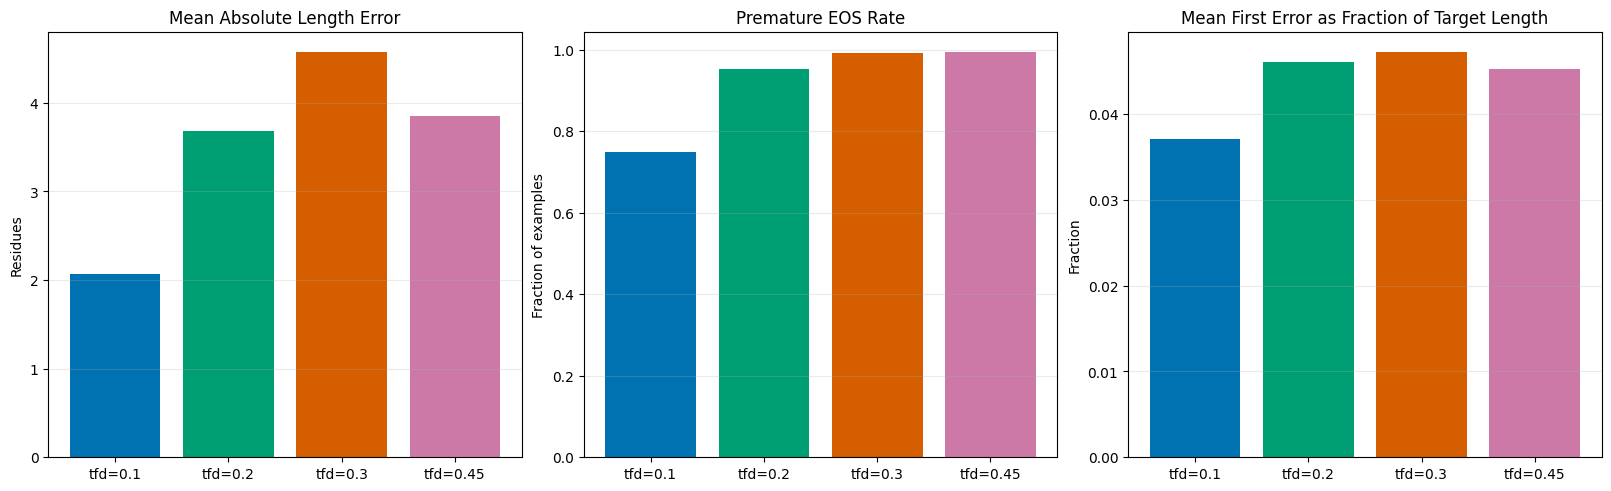

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
bar_df = v11_eos_summary.copy()
bar_df["plot_label"] = bar_df["teacher_forcing_dropout"].map(lambda x: f"tfd={x:g}")
colors = [v11_colors.get(tfd, "#666666") for tfd in bar_df["teacher_forcing_dropout"]]

axes[0].bar(bar_df["plot_label"], bar_df["mean_abs_length_error"], color=colors)
axes[0].set_title("Mean Absolute Length Error")
axes[0].set_ylabel("Residues")
axes[1].bar(bar_df["plot_label"], bar_df.get("premature", 0), color=colors)
axes[1].set_title("Premature EOS Rate")
axes[1].set_ylabel("Fraction of examples")
axes[2].bar(bar_df["plot_label"], bar_df["mean_first_error_fraction"], color=colors)
axes[2].set_title("Mean First Error as Fraction of Target Length")
axes[2].set_ylabel("Fraction")
for ax in axes:
    ax.grid(axis="y", alpha=0.25)
plt.show()



##### Per-Position Accuracy

Absolute-position curves show where early-token reconstruction fails. Relative-position bins make runs comparable across different sequence lengths.


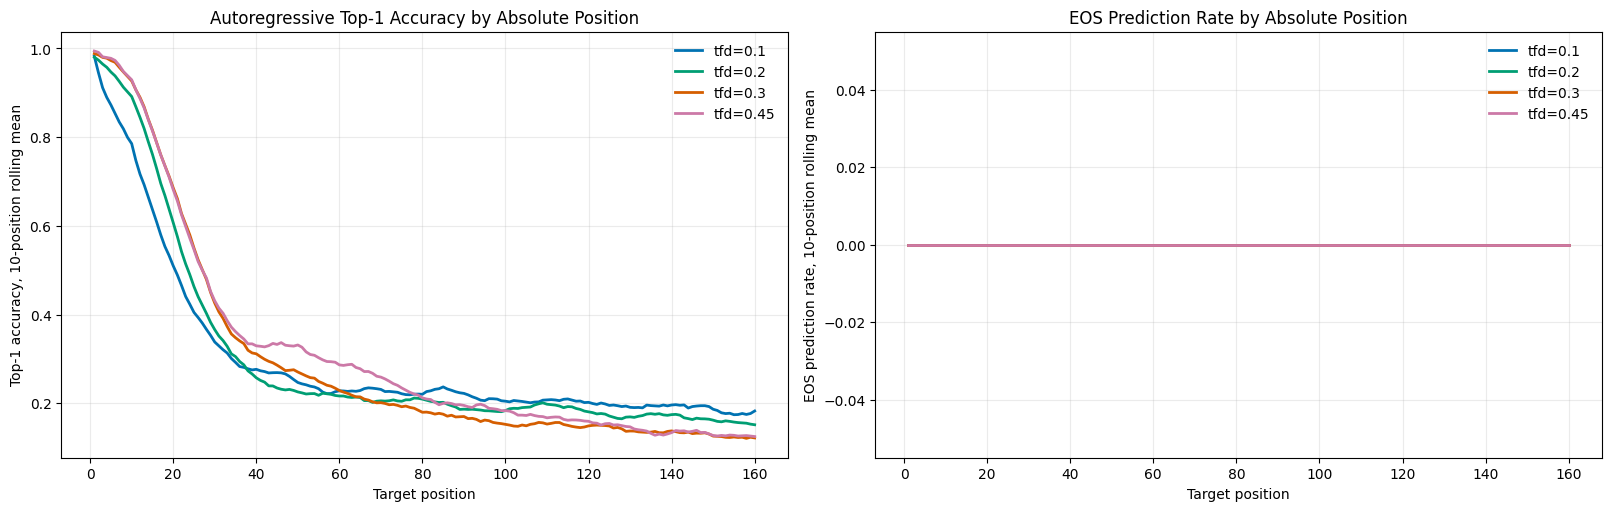

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
max_position_to_plot = 160
for tfd, data in v11_position_df.loc[v11_position_df["position"].le(max_position_to_plot)].groupby("teacher_forcing_dropout"):
    label = f"tfd={tfd:g}"
    color = v11_colors.get(tfd, "#666666")
    smoothed = data.sort_values("position").copy()
    smoothed["top1_smoothed"] = smoothed["top1_accuracy"].rolling(10, min_periods=1).mean()
    smoothed["eos_smoothed"] = smoothed["eos_prediction_rate"].rolling(10, min_periods=1).mean()
    axes[0].plot(smoothed["position"], smoothed["top1_smoothed"], label=label, color=color, linewidth=2)
    axes[1].plot(smoothed["position"], smoothed["eos_smoothed"], label=label, color=color, linewidth=2)

axes[0].set_title("Autoregressive Top-1 Accuracy by Absolute Position")
axes[0].set_ylabel("Top-1 accuracy, 10-position rolling mean")
axes[1].set_title("EOS Prediction Rate by Absolute Position")
axes[1].set_ylabel("EOS prediction rate, 10-position rolling mean")
for ax in axes:
    ax.set_xlabel("Target position")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()



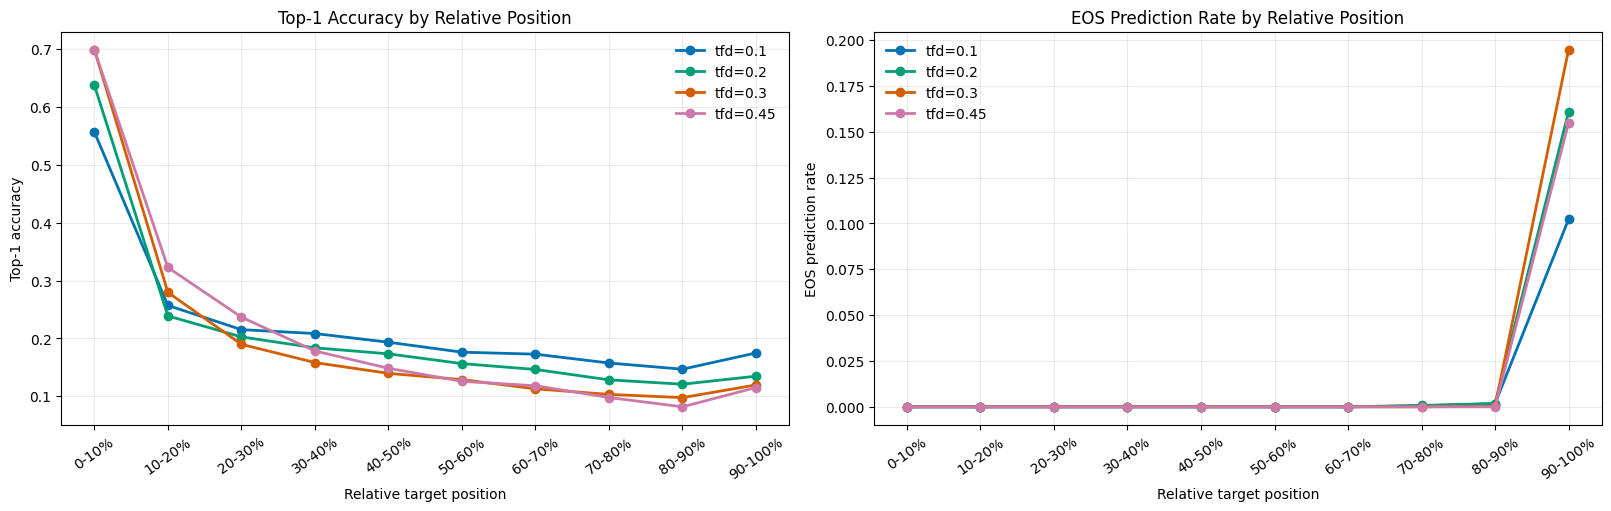

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
for tfd, data in v11_relative_position_df.groupby("teacher_forcing_dropout"):
    data = data.sort_values("relative_position_bin")
    label = f"tfd={tfd:g}"
    color = v11_colors.get(tfd, "#666666")
    axes[0].plot(data["relative_position_label"], data["top1_accuracy"], marker="o", label=label, color=color, linewidth=2)
    axes[1].plot(data["relative_position_label"], data["eos_prediction_rate"], marker="o", label=label, color=color, linewidth=2)

axes[0].set_title("Top-1 Accuracy by Relative Position")
axes[0].set_ylabel("Top-1 accuracy")
axes[1].set_title("EOS Prediction Rate by Relative Position")
axes[1].set_ylabel("EOS prediction rate")
for ax in axes:
    ax.set_xlabel("Relative target position")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()



##### Focused Takeaway for Next Steps

If `tfd=0.1` has the best early-position accuracy and the lowest EOS/length error, it should remain the default dropout setting. If EOS rates spike around a consistent absolute or relative position, the next change should target EOS handling rather than teacher-forcing dropout. Useful follow-ups include evaluating with EOS disabled during greedy decoding, adding an EOS penalty/min-length constraint at inference, or downweighting EOS during training/evaluation to test whether the decoder is overusing the stop token.
